# 🤖 ScoutIQ — 03 · Multi-Model Development, Hyperparameter Tuning & Explainability
---
**ScoutIQ Football Intelligence Platform** | Notebook 3 of 3

### Pipeline
1. Data preparation & feature matrix
2. Baseline benchmark — 7 algorithms, 5-fold CV
3. Per-model hyperparameter tuning (RandomizedSearchCV)
4. Ensemble & Voting Classifier
5. Full model comparison (AUC, Accuracy, F1, Log-Loss, PR-AUC)
6. Final model: ROC, PR curve, confusion matrix, calibration
7. Learning curves & bias-variance analysis
8. SHAP / coefficient explainability
9. Submission generation


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, sys, json, time, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

from sklearn.model_selection import (StratifiedKFold, cross_val_score,
    RandomizedSearchCV, GridSearchCV, learning_curve, cross_validate)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, VotingClassifier, BaggingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score, log_loss,
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, matthews_corrcoef,
    balanced_accuracy_score, brier_score_loss)

try:   from xgboost  import XGBClassifier;  HAS_XGB=True
except: HAS_XGB=False
try:   from lightgbm import LGBMClassifier; HAS_LGB=True
except: HAS_LGB=False

DARK='#080c14'; CARD='#111827'; MID='#1e2a3a'; TXT='#f1f5f9'; SUB='#94a3b8'; MUTED='#475569'
C_GREEN='#00e676'; C_BLUE='#2979ff'; C_GOLD='#ffd600'
C_RED='#ff1744'; C_CYAN='#00e5ff'; C_ORANGE='#ff6d00'

plt.rcParams.update({'figure.facecolor':DARK,'axes.facecolor':CARD,'axes.edgecolor':MID,
    'axes.labelcolor':SUB,'xtick.color':MUTED,'ytick.color':MUTED,'text.color':TXT,
    'grid.color':MID,'grid.linewidth':0.5,'axes.grid':True,'figure.dpi':110,
    'font.family':'DejaVu Sans','axes.spines.top':False,'axes.spines.right':False,
    'legend.framealpha':0.15,'legend.edgecolor':MID})

print(f'XGBoost : {HAS_XGB} | LightGBM: {HAS_LGB}')


XGBoost : True | LightGBM: True


## 1 · Data Preparation


In [2]:
# ── Load & Prepare Data ──────────────────────────────────────────────────────
from data_preprocessing import load_raw_data, clean_and_process
from feature_engineering import get_all_feature_cols, prepare_X_y

train_raw = load_raw_data('train')
test_raw  = load_raw_data('test')
train_df  = clean_and_process(train_raw.copy(), is_train=True)
test_df   = clean_and_process(test_raw.copy(),  is_train=False)

feat_cols = get_all_feature_cols(train_df)
X, y      = prepare_X_y(train_df, feat_cols)

# Force everything to float64 to avoid isfinite / bool dtype issues
X_arr = np.array(X, dtype=np.float64)
y_arr = np.array(y, dtype=np.int64)
X_arr = np.ascontiguousarray(X_arr, dtype=np.float64)

print(f'Train   : {X_arr.shape[0]} rows x {X_arr.shape[1]} features  dtype={X_arr.dtype}')
print(f'Target  : winner  {np.bincount(y_arr)}  ({y_arr.mean()*100:.1f}% wins)')
print(f'Features: {len(feat_cols)}')


2026-05-26 12:05:32,570 - INFO - Loaded train data: 1000 rows × 26 cols


2026-05-26 12:05:32,573 - INFO - Loaded test data: 250 rows × 25 cols


2026-05-26 12:05:32,582 - INFO - Feature engineering complete — added 10 derived features


2026-05-26 12:05:32,592 - INFO - Feature engineering complete — added 10 derived features


Train   : 1000 rows x 40 features  dtype=float64
Target  : winner  [527 473]  (47.3% wins)
Features: 40


## 2 · Baseline Benchmark — 7 Models, 5-Fold CV


In [3]:
# ── Pipeline Builder ─────────────────────────────────────────────────────────
def make_pipe(clf, scaler=None):
    scaler = scaler or RobustScaler()
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  scaler),
        ('clf',     clf),
    ])

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Candidate Models ──────────────────────────────────────────────────────────
candidates = {
    'Logistic Regression': make_pipe(LogisticRegression(max_iter=1000, random_state=42)),
    'Random Forest':       make_pipe(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    'Extra Trees':         make_pipe(ExtraTreesClassifier(n_estimators=100,  random_state=42, n_jobs=-1)),
    'Gradient Boosting':   make_pipe(GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, random_state=42)),
    'Gaussian NaiveBayes': make_pipe(GaussianNB()),
}
if HAS_XGB:
    candidates['XGBoost']  = make_pipe(XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42, eval_metric='logloss', use_label_encoder=False))
if HAS_LGB:
    candidates['LightGBM'] = make_pipe(LGBMClassifier(n_estimators=150, learning_rate=0.05, random_state=42, verbose=-1))

print(f'Models to benchmark: {len(candidates)}')
print(list(candidates.keys()))


Models to benchmark: 7
['Logistic Regression', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'Gaussian NaiveBayes', 'XGBoost', 'LightGBM']


In [4]:
# ── 5-Fold Cross-Validation — All Models ─────────────────────────────────────
scoring = {
    'roc_auc':  'roc_auc',
    'accuracy': 'accuracy',
    'f1':       'f1',
    'neg_log_loss': 'neg_log_loss',
    'average_precision': 'average_precision',
}

all_results = {}
print(f'{"Model":<22} {"AUC":>7} {"±":>6} {"Acc":>7} {"F1":>7} {"PR-AUC":>8} {"LogLoss":>9} {"Time":>7}')
print('─' * 78)

for name, pipe in candidates.items():
    t0  = time.time()
    cv  = cross_validate(pipe, X_arr, y_arr.astype(float), cv=SKF, scoring=scoring, n_jobs=-1)
    sec = round(time.time()-t0, 2)

    auc_m   = cv['test_roc_auc'].mean()
    auc_s   = cv['test_roc_auc'].std()
    acc_m   = cv['test_accuracy'].mean()
    f1_m    = cv['test_f1'].mean()
    prauc_m = cv['test_average_precision'].mean()
    ll_m    = -cv['test_neg_log_loss'].mean()

    all_results[name] = {
        'AUC': round(auc_m, 4), 'AUC_std': round(auc_s, 4),
        'Accuracy': round(acc_m, 4), 'F1': round(f1_m, 4),
        'PR_AUC': round(prauc_m, 4), 'LogLoss': round(ll_m, 4),
        'Time_s': sec, 'auc_folds': cv['test_roc_auc'].tolist()
    }
    print(f'{name:<22} {auc_m:>7.4f} {auc_s:>6.4f} {acc_m:>7.4f} {f1_m:>7.4f} '
          f'{prauc_m:>8.4f} {ll_m:>9.4f} {sec:>6.2f}s')

results_df = (pd.DataFrame(all_results).T
              .sort_values('AUC', ascending=False)
              .reset_index().rename(columns={'index':'Model'}))
print()
print(f'Best baseline: {results_df.iloc[0]["Model"]} (AUC={results_df.iloc[0]["AUC"]:.4f})')


Model                      AUC      ±     Acc      F1   PR-AUC   LogLoss    Time
──────────────────────────────────────────────────────────────────────────────


Logistic Regression     0.7128 0.0410  0.6630  0.6341   0.6707    0.6286   0.15s


Random Forest           0.6813 0.0345  0.6330  0.5869   0.6282    0.6546   1.60s


Extra Trees             0.6838 0.0459  0.6450  0.6143   0.6442    0.6491   1.15s


Gradient Boosting       0.6772 0.0425  0.6450  0.6047   0.6182    0.6595   2.52s
Gaussian NaiveBayes     0.7050 0.0474  0.6430  0.5952   0.6635    5.0360   0.11s


XGBoost                 0.6708 0.0372  0.6300  0.5903   0.6180    0.6866   0.83s


LightGBM                0.6462 0.0392  0.6180  0.5816   0.6010    0.7996   1.21s

Best baseline: Logistic Regression (AUC=0.7128)


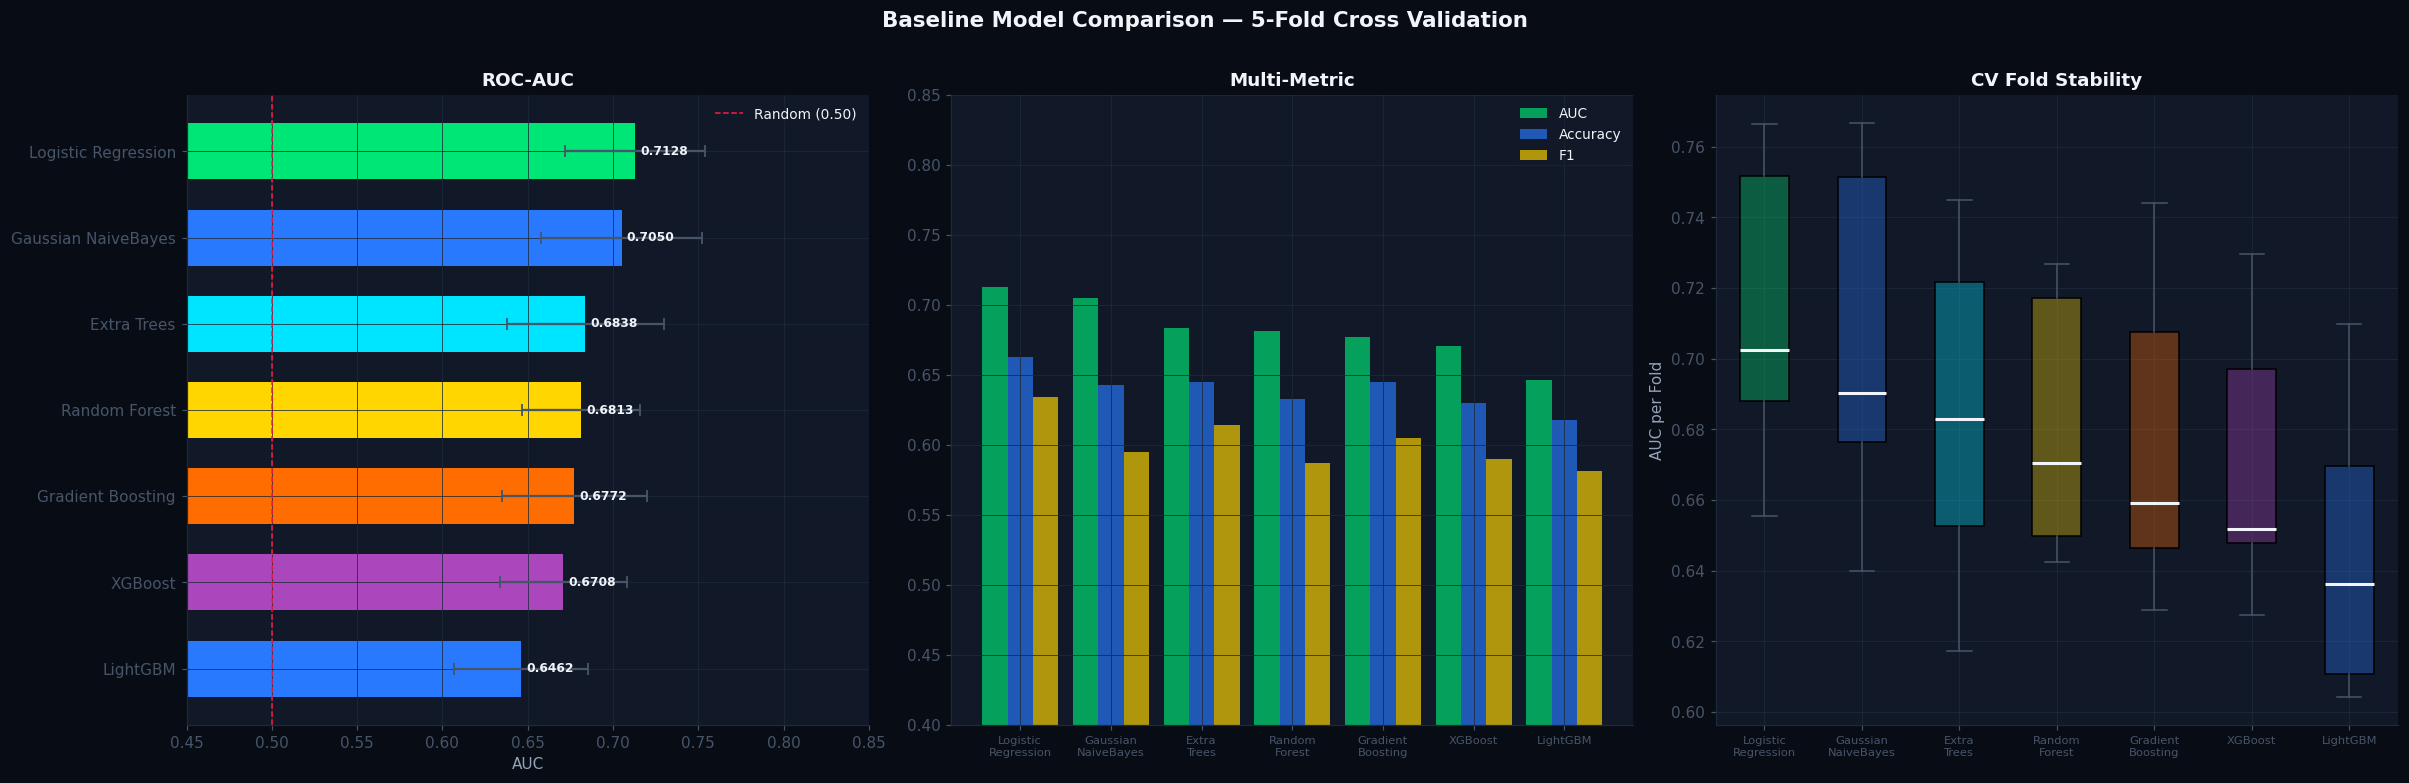

In [5]:
# ── Baseline Visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Baseline Model Comparison — 5-Fold Cross Validation',
             fontsize=14, fontweight='bold', y=1.01)

models  = results_df['Model'].tolist()
aucs    = results_df['AUC'].astype(float).tolist()
stds    = results_df['AUC_std'].astype(float).tolist()
accs    = results_df['Accuracy'].astype(float).tolist()
f1s     = results_df['F1'].astype(float).tolist()
pr_aucs = results_df['PR_AUC'].astype(float).tolist()
lloss   = results_df['LogLoss'].astype(float).tolist()

palette = [C_GREEN, C_BLUE, C_CYAN, C_GOLD, C_ORANGE, '#ab47bc', C_TEAL if 'C_TEAL' in dir() else C_BLUE, '#ef5350', '#26a69a']
bar_colors = [palette[i % len(palette)] for i in range(len(models))]
bar_colors[0] = C_GREEN  # best model always green

# Panel 1: AUC
bars = axes[0].barh(models[::-1], aucs[::-1], xerr=stds[::-1],
                    color=bar_colors[::-1], edgecolor='none', height=0.65,
                    error_kw=dict(ecolor=MUTED, capsize=4, capthick=1.2))
axes[0].axvline(0.5, color=C_RED, linewidth=1, linestyle='--', label='Random (0.50)')
for bar, val in zip(bars, aucs[::-1]):
    axes[0].text(val+0.003, bar.get_y()+bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8, color=TXT, fontweight='bold')
axes[0].set_xlim(0.45, 0.85); axes[0].set_title('ROC-AUC', fontweight='bold', fontsize=12)
axes[0].set_xlabel('AUC'); axes[0].legend(fontsize=9)

# Panel 2: Multi-metric grouped bar
x = np.arange(len(models))
w = 0.28
axes[1].bar(x-w,  aucs,    w, color=C_GREEN+'aa',  label='AUC',      edgecolor='none')
axes[1].bar(x,    accs,    w, color=C_BLUE+'aa',   label='Accuracy',  edgecolor='none')
axes[1].bar(x+w,  f1s,     w, color=C_GOLD+'aa',   label='F1',        edgecolor='none')
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace(' ','\n') for m in models], fontsize=7.5, rotation=0)
axes[1].set_ylim(0.40, 0.85); axes[1].set_title('Multi-Metric', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)

# Panel 3: Fold stability (box per model)
fold_data = [results_df.loc[results_df['Model']==m,'auc_folds'].values[0] for m in models]
bp = axes[2].boxplot(fold_data, patch_artist=True, widths=0.5,
                     medianprops=dict(color=TXT, linewidth=2),
                     whiskerprops=dict(color=MUTED),
                     capprops=dict(color=MUTED),
                     flierprops=dict(marker='.', color=C_RED, markersize=6))
for patch, color in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(color + '55')
axes[2].set_xticklabels([m.replace(' ','\n') for m in models], fontsize=7.5)
axes[2].set_title('CV Fold Stability', fontweight='bold', fontsize=12)
axes[2].set_ylabel('AUC per Fold')

plt.tight_layout()
plt.show()


## 3 · Per-Model Hyperparameter Tuning
Each model is tuned independently with domain-specific search spaces.


In [6]:
# ── Hyperparameter Search Spaces ─────────────────────────────────────────────
search_spaces = {
    'Logistic Regression': (
        make_pipe(LogisticRegression(max_iter=1000, random_state=42)),
        {'clf__C':          [0.01, 0.1, 1.0, 5.0, 10.0],
         'clf__solver':     ['lbfgs', 'saga'],
         'clf__penalty':    ['l2'],
         'clf__class_weight': [None, 'balanced']}
    ),
    'Random Forest': (
        make_pipe(RandomForestClassifier(random_state=42, n_jobs=-1)),
        {'clf__n_estimators':     [100, 200],
         'clf__max_depth':        [None, 10, 15],
         'clf__min_samples_split':[2, 5],
         'clf__max_features':     ['sqrt', 'log2']}
    ),
    'Extra Trees': (
        make_pipe(ExtraTreesClassifier(random_state=42, n_jobs=-1)),
        {'clf__n_estimators':     [100, 200],
         'clf__max_depth':        [None, 10, 15],
         'clf__min_samples_split':[2, 5],
         'clf__max_features':     ['sqrt', 'log2']}
    ),
    'Gradient Boosting': (
        make_pipe(GradientBoostingClassifier(random_state=42)),
        {'clf__n_estimators':  [100, 150],
         'clf__learning_rate': [0.02, 0.05, 0.1],
         'clf__max_depth':     [3, 4, 5],
         'clf__subsample':     [0.8, 0.9]}
    ),
}
if HAS_XGB:
    search_spaces['XGBoost'] = (
        make_pipe(XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)),
        {'clf__n_estimators':    [100, 150],
         'clf__max_depth':       [3, 4, 5],
         'clf__learning_rate':   [0.02, 0.05, 0.1],
         'clf__subsample':       [0.7, 0.8, 0.9],
         'clf__colsample_bytree':[0.7, 0.8]}
    )
if HAS_LGB:
    search_spaces['LightGBM'] = (
        make_pipe(LGBMClassifier(random_state=42, verbose=-1)),
        {'clf__n_estimators':    [100, 150],
         'clf__max_depth':       [-1, 5, 7],
         'clf__learning_rate':   [0.02, 0.05, 0.1],
         'clf__num_leaves':      [31, 63],
         'clf__subsample':       [0.7, 0.8]}
    )

print(f'Models to tune: {len(search_spaces)}')
for name, (pipe, params) in search_spaces.items():
    print(f'  {name:<25} {len(params)} param dims')


Models to tune: 6
  Logistic Regression       4 param dims
  Random Forest             4 param dims
  Extra Trees               4 param dims
  Gradient Boosting         4 param dims
  XGBoost                   5 param dims
  LightGBM                  5 param dims


In [7]:
# ── Run Tuning — All Models ──────────────────────────────────────────────────
N_ITER  = 10   # iterations per model
N_FOLDS = 5

tuned_models  = {}
tuning_results= {}

print('Hyperparameter Tuning Progress:')
print('─' * 70)

for name, (pipe, param_dist) in search_spaces.items():
    t0 = time.time()
    search = RandomizedSearchCV(
        pipe, param_dist,
        n_iter=N_ITER, cv=SKF,
        scoring='roc_auc', n_jobs=-1,
        random_state=42, verbose=0,
        return_train_score=True,
        refit=True,
    )
    search.fit(X_arr, y_arr)
    elapsed = time.time() - t0

    tuned_models[name]   = search.best_estimator_
    tuning_results[name] = {
        'best_score':  round(search.best_score_, 4),
        'best_params': search.best_params_,
        'time_s':      round(elapsed, 1),
        'cv_results':  search.cv_results_,
    }

    baseline_auc = float(results_df.loc[results_df['Model']==name,'AUC'].values[0])                    if name in results_df['Model'].values else 0.0
    delta = search.best_score_ - baseline_auc
    print(f'  {name:<22} baseline={baseline_auc:.4f}  tuned={search.best_score_:.4f}  '
          f'Δ={delta:+.4f}  ({elapsed:.1f}s)')

print()
print('Tuning complete.')


Hyperparameter Tuning Progress:
──────────────────────────────────────────────────────────────────────


  Logistic Regression    baseline=0.7128  tuned=0.7161  Δ=+0.0033  (2.7s)


  Random Forest          baseline=0.6813  tuned=0.6952  Δ=+0.0139  (25.0s)


  Extra Trees            baseline=0.6838  tuned=0.7021  Δ=+0.0183  (17.4s)


  Gradient Boosting      baseline=0.6772  tuned=0.6975  Δ=+0.0203  (36.4s)


  XGBoost                baseline=0.6708  tuned=0.7045  Δ=+0.0337  (6.6s)


  LightGBM               baseline=0.6462  tuned=0.6827  Δ=+0.0365  (8.5s)

Tuning complete.


In [8]:
# ── Best Params Summary ───────────────────────────────────────────────────────
print('Best Hyperparameters Found:')
print('═' * 65)
for name, res in tuning_results.items():
    print(f'\n  {name}  (CV AUC={res["best_score"]:.4f})')
    for k, v in res['best_params'].items():
        print(f'    {k.replace("clf__",""):<25}: {v}')


Best Hyperparameters Found:
═════════════════════════════════════════════════════════════════

  Logistic Regression  (CV AUC=0.7161)
    solver                   : saga
    penalty                  : l2
    class_weight             : None
    C                        : 0.1

  Random Forest  (CV AUC=0.6952)
    n_estimators             : 200
    min_samples_split        : 2
    max_features             : log2
    max_depth                : 10

  Extra Trees  (CV AUC=0.7021)
    n_estimators             : 200
    min_samples_split        : 2
    max_features             : log2
    max_depth                : 15

  Gradient Boosting  (CV AUC=0.6975)
    subsample                : 0.8
    n_estimators             : 100
    max_depth                : 5
    learning_rate            : 0.02

  XGBoost  (CV AUC=0.7045)
    subsample                : 0.8
    n_estimators             : 150
    max_depth                : 3
    learning_rate            : 0.02
    colsample_bytree         : 0.7

  L

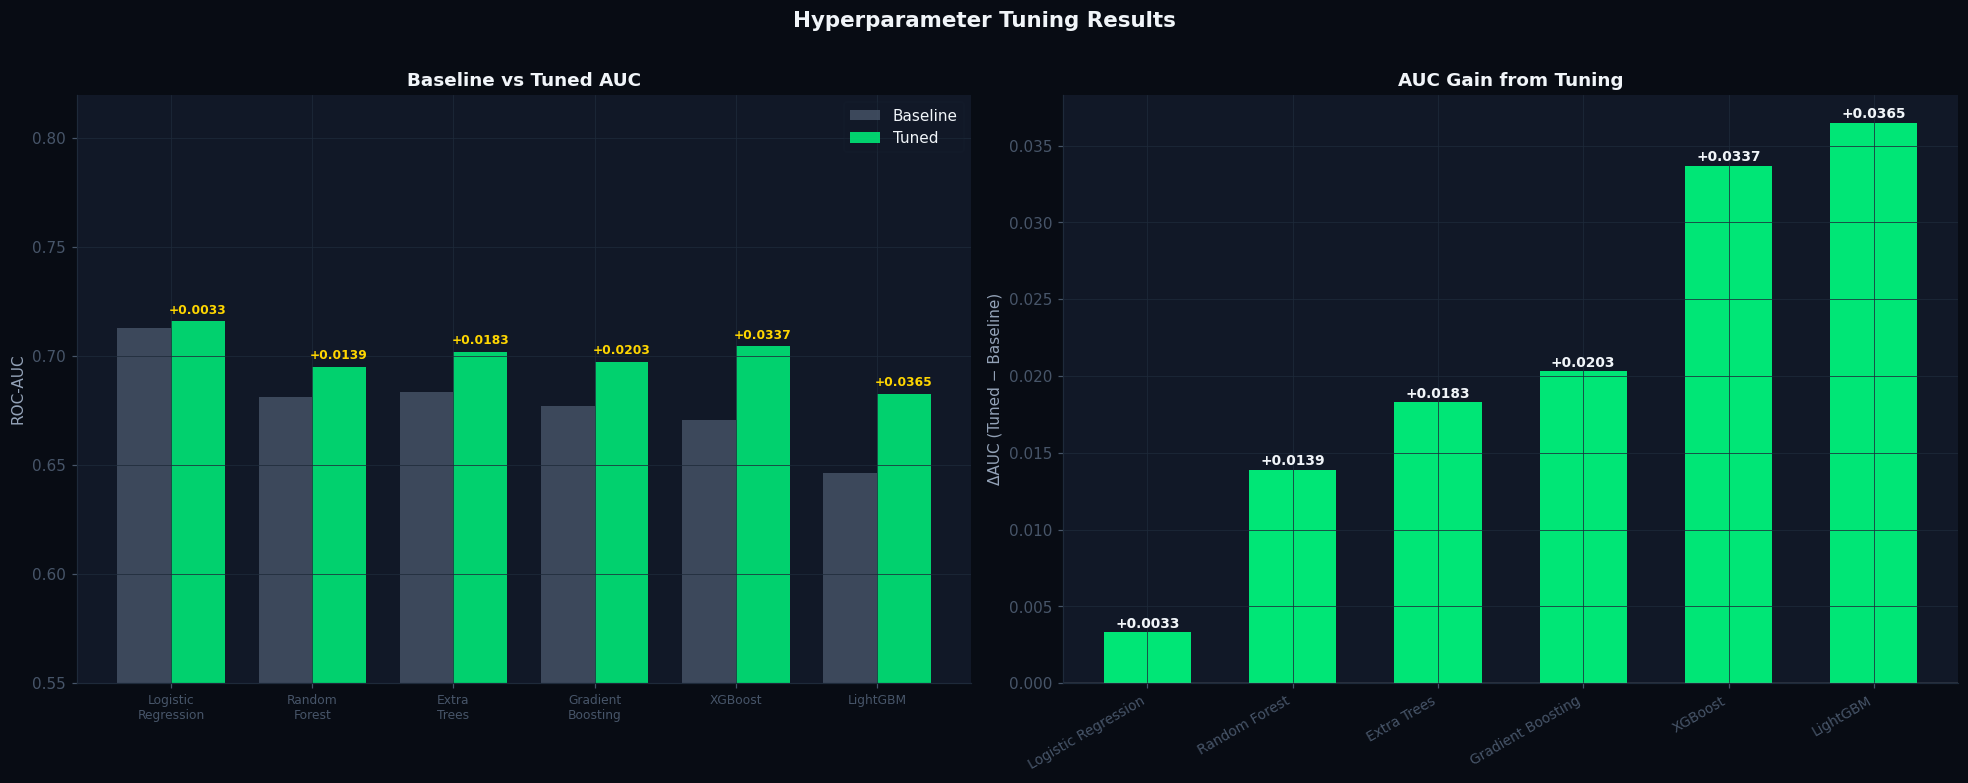

In [9]:
# ── Tuning Gain Chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Hyperparameter Tuning Results', fontsize=14, fontweight='bold', y=1.01)

tuned_aucs    = {n: v['best_score'] for n, v in tuning_results.items()}
baseline_aucs = {n: float(results_df.loc[results_df['Model']==n,'AUC'].values[0])
                 for n in tuning_results if n in results_df['Model'].values}
common_names  = list(tuned_aucs.keys())

base_vals  = [baseline_aucs.get(n, 0) for n in common_names]
tuned_vals = [tuned_aucs[n]           for n in common_names]
deltas     = [t - b for t, b in zip(tuned_vals, base_vals)]

x  = np.arange(len(common_names))
w  = 0.38
axes[0].bar(x-w/2, base_vals,  w, color=MUTED, label='Baseline', edgecolor='none', alpha=0.8)
axes[0].bar(x+w/2, tuned_vals, w, color=C_GREEN, label='Tuned',   edgecolor='none', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace(' ','\n') for n in common_names], fontsize=8)
axes[0].set_ylim(0.55, 0.82)
axes[0].set_title('Baseline vs Tuned AUC', fontweight='bold', fontsize=12)
axes[0].set_ylabel('ROC-AUC')
axes[0].legend(fontsize=10)

for xi, (bv, tv) in enumerate(zip(base_vals, tuned_vals)):
    axes[0].annotate(f'+{tv-bv:.4f}', xy=(xi+w/2, tv),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', fontsize=8, color=C_GOLD, fontweight='bold')

# Delta chart
delta_colors = [C_GREEN if d >= 0 else C_RED for d in deltas]
axes[1].bar(common_names, deltas, color=delta_colors, edgecolor='none', width=0.6)
axes[1].axhline(0, color=TXT, linewidth=0.8)
for xi, d in enumerate(deltas):
    axes[1].text(xi, d + (0.0003 if d >= 0 else -0.0008), f'{d:+.4f}',
                 ha='center', fontsize=9, fontweight='bold', color=TXT)
axes[1].set_xticklabels(common_names, rotation=30, ha='right', fontsize=9)
axes[1].set_title('AUC Gain from Tuning', fontweight='bold', fontsize=12)
axes[1].set_ylabel('ΔAUC (Tuned − Baseline)')
plt.tight_layout()
plt.show()


## 4 · Ensemble — Voting Classifier


In [10]:
# ── Build Voting Ensemble from Top 3 Tuned Models ────────────────────────────
# Rank tuned models and pick top 3 for ensemble
tuned_ranked = sorted(tuning_results.items(), key=lambda x: x[1]['best_score'], reverse=True)
top3_names   = [n for n, _ in tuned_ranked[:3]]
top3_pipes   = [(n, tuned_models[n]) for n in top3_names]

print('Top 3 tuned models selected for ensemble:')
for n in top3_names:
    print(f'  {n:<25} AUC={tuning_results[n]["best_score"]:.4f}')

# Soft Voting Ensemble
ensemble_soft = VotingClassifier(estimators=top3_pipes, voting='soft', n_jobs=-1)
ensemble_cv_soft = cross_val_score(ensemble_soft, X_arr, y_arr, cv=SKF,
                                    scoring='roc_auc', n_jobs=-1)

# Hard Voting Ensemble
ensemble_hard = VotingClassifier(estimators=top3_pipes, voting='hard', n_jobs=-1)
ensemble_cv_hard = cross_val_score(ensemble_hard, X_arr, y_arr, cv=SKF,
                                    scoring='roc_auc', n_jobs=-1)

print()
print(f'Soft Voting Ensemble AUC: {ensemble_cv_soft.mean():.4f} ± {ensemble_cv_soft.std():.4f}')
print(f'Hard Voting Ensemble AUC: {ensemble_cv_hard.mean():.4f} ± {ensemble_cv_hard.std():.4f}')
print(f'Best individual tuned:    {tuned_ranked[0][1]["best_score"]:.4f}  ({top3_names[0]})')

# Add to results
tuning_results['Soft Voting (Top3)'] = {'best_score': round(ensemble_cv_soft.mean(),4), 'best_params':{}, 'time_s':0}
tuning_results['Hard Voting (Top3)'] = {'best_score': round(ensemble_cv_hard.mean(),4), 'best_params':{}, 'time_s':0}


Top 3 tuned models selected for ensemble:
  Logistic Regression       AUC=0.7161
  XGBoost                   AUC=0.7045
  Extra Trees               AUC=0.7021



Soft Voting Ensemble AUC: 0.7136 ± 0.0476
Hard Voting Ensemble AUC: nan ± nan
Best individual tuned:    0.7161  (Logistic Regression)


## 5 · Full Final Model Comparison


In [11]:
# ── Train Each Tuned Model on Full Data — Comprehensive Evaluation ─────────
final_metrics = {}
tuned_fitted  = {}

for name, pipe in tuned_models.items():
    pipe.fit(X_arr, y_arr)
    y_prob = pipe.predict_proba(X_arr)[:, 1].astype(np.float64).astype(float)
    y_pred = pipe.predict(X_arr)
    tuned_fitted[name] = pipe

    final_metrics[name] = {
        'Train AUC':     round(roc_auc_score(y_arr, y_prob),      4),
        'Train Acc':     round(accuracy_score(y_arr, y_pred),     4),
        'Train F1':      round(f1_score(y_arr, y_pred),           4),
        'Train LogLoss': round(log_loss(y_arr, y_prob),           4),
        'Train PR-AUC':  round(average_precision_score(y_arr, y_prob), 4),
        'MCC':           round(matthews_corrcoef(y_arr, y_pred),  4),
        'Bal Acc':       round(balanced_accuracy_score(y_arr, y_pred), 4),
        'Brier':         round(brier_score_loss(y_arr, y_prob),   4),
        'CV AUC':        tuning_results[name]['best_score'],
    }

# Combine CV + train metrics into one comparison table
comp_df = pd.DataFrame(final_metrics).T.reset_index().rename(columns={'index':'Model'})
comp_df = comp_df.sort_values('CV AUC', ascending=False)

print('Final Model Comparison (Tuned):')
print(comp_df.to_string(index=False))


Final Model Comparison (Tuned):
              Model  Train AUC  Train Acc  Train F1  Train LogLoss  Train PR-AUC    MCC  Bal Acc  Brier  CV AUC
Logistic Regression     0.7391      0.668    0.6376         0.6008        0.6975 0.3325   0.6654 0.2067  0.7161
            XGBoost     0.8427      0.771    0.7470         0.5280        0.8268 0.5405   0.7681 0.1738  0.7045
        Extra Trees     1.0000      1.000    1.0000         0.0672        1.0000 1.0000   1.0000 0.0057  0.7021
  Gradient Boosting     0.9539      0.869    0.8590         0.4317        0.9522 0.7372   0.8677 0.1290  0.6975
      Random Forest     0.9999      0.994    0.9936         0.2766        0.9999 0.9880   0.9937 0.0654  0.6952
           LightGBM     0.9167      0.821    0.8069         0.4705        0.9102 0.6407   0.8194 0.1474  0.6827


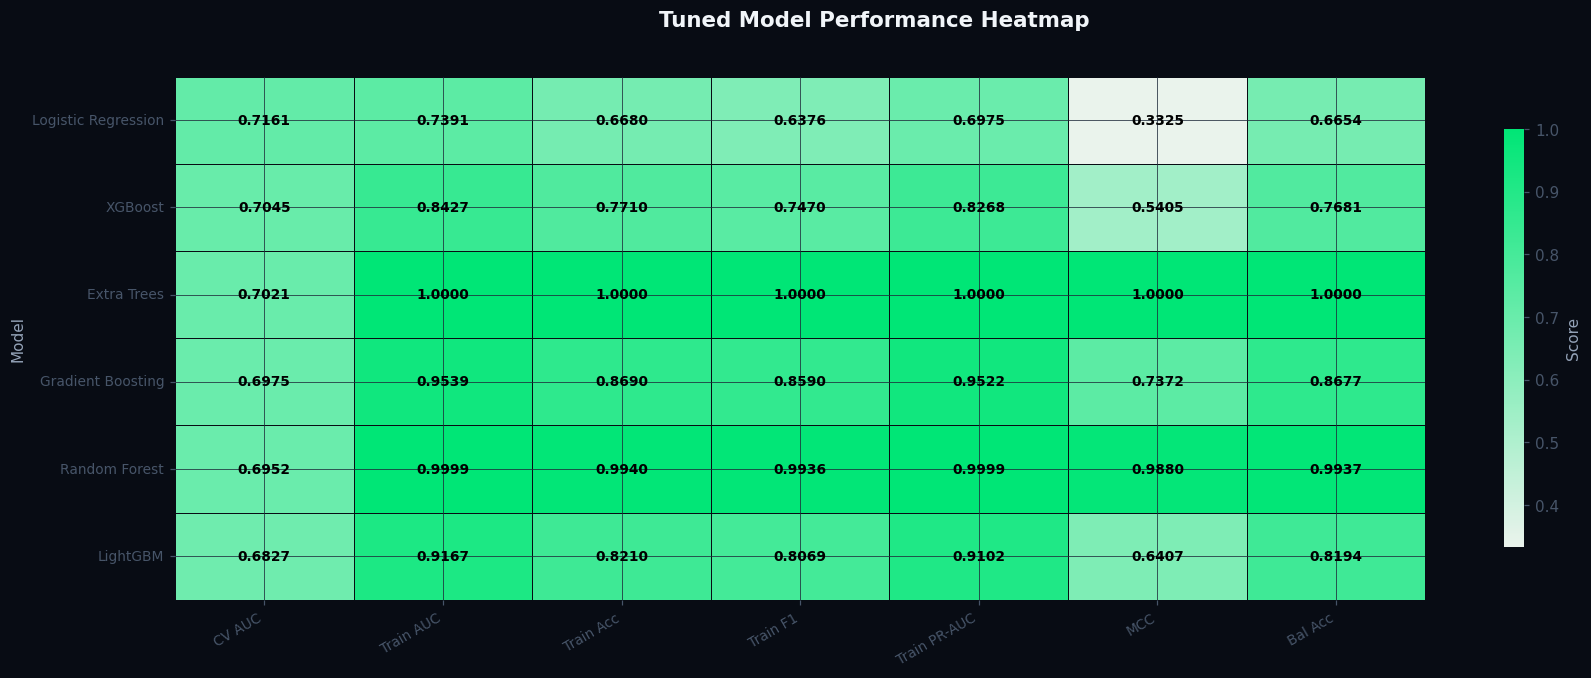

In [12]:
# ── Comprehensive Comparison Heatmap ─────────────────────────────────────────
metric_cols = ['CV AUC','Train AUC','Train Acc','Train F1','Train PR-AUC','MCC','Bal Acc']
inverted    = ['Train LogLoss','Brier']   # lower is better

hm_data = comp_df.set_index('Model')[metric_cols].astype(float)

fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('Tuned Model Performance Heatmap', fontsize=14, fontweight='bold', y=1.02)

cmap = sns.light_palette(C_GREEN, as_cmap=True)
sns.heatmap(hm_data, cmap=cmap, annot=True, fmt='.4f',
            annot_kws={'size':9,'color':'black','fontweight':'bold'},
            linewidths=0.5, linecolor=DARK, ax=ax, cbar=True,
            cbar_kws={'label':'Score','shrink':0.8})
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


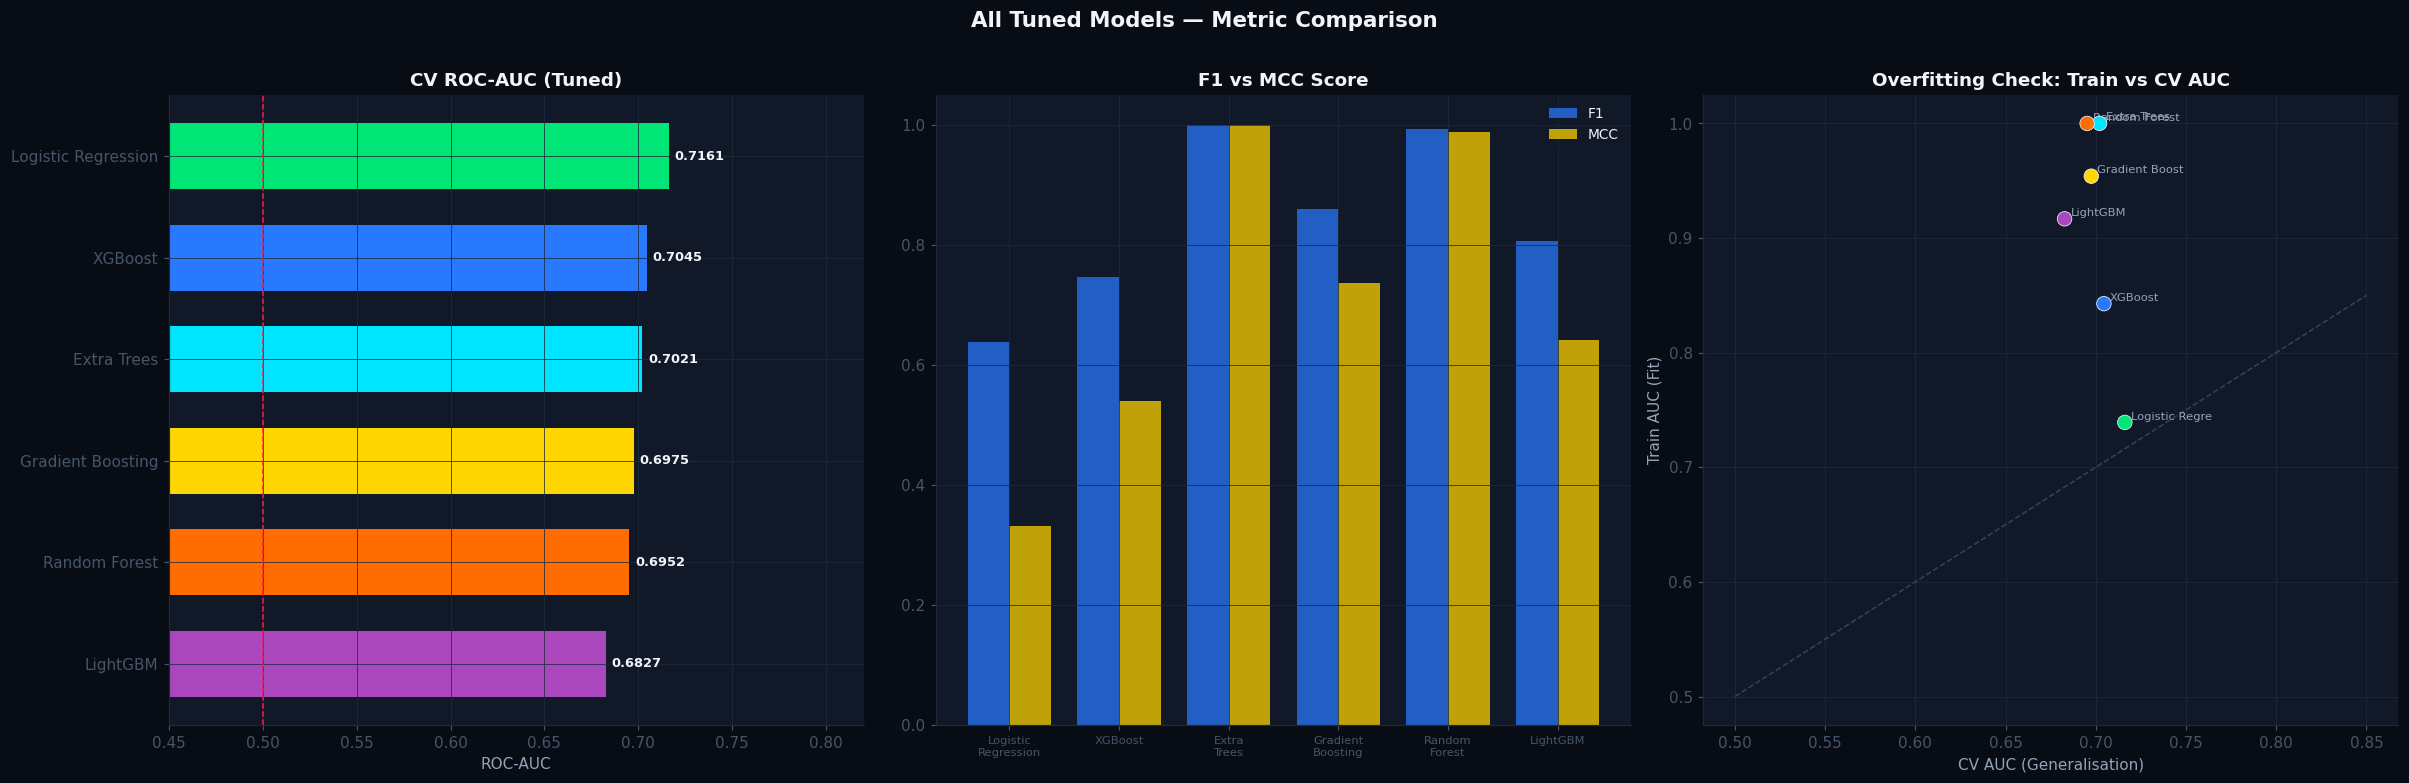

In [13]:
# ── Full Comparison Bar Chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('All Tuned Models — Metric Comparison', fontsize=14, fontweight='bold', y=1.01)

model_names = comp_df['Model'].tolist()
cv_aucs     = comp_df['CV AUC'].astype(float).tolist()
train_aucs  = comp_df['Train AUC'].astype(float).tolist()
f1_vals     = comp_df['Train F1'].astype(float).tolist()
mcc_vals    = comp_df['MCC'].astype(float).tolist()

palette = [C_GREEN,C_BLUE,C_CYAN,C_GOLD,C_ORANGE,'#ab47bc','#ef5350','#26a69a','#ec407a']
bar_c   = [palette[i%len(palette)] for i in range(len(model_names))]
bar_c[0]= C_GREEN

# AUC comparison
bars = axes[0].barh(model_names[::-1], cv_aucs[::-1],
                    color=bar_c[::-1], edgecolor='none', height=0.65)
axes[0].axvline(0.5, color=C_RED, linewidth=1, linestyle='--')
for bar, v in zip(bars, cv_aucs[::-1]):
    axes[0].text(v+0.003, bar.get_y()+bar.get_height()/2, f'{v:.4f}',
                 va='center', fontsize=8.5, fontweight='bold', color=TXT)
axes[0].set_title('CV ROC-AUC (Tuned)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('ROC-AUC'); axes[0].set_xlim(0.45,0.82)

# F1 + MCC
x = np.arange(len(model_names))
w = 0.38
axes[1].bar(x-w/2, f1_vals,  w, color=C_BLUE+'bb', label='F1',  edgecolor='none')
axes[1].bar(x+w/2, mcc_vals, w, color=C_GOLD+'bb', label='MCC', edgecolor='none')
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(' ','\n') for n in model_names], fontsize=7.5)
axes[1].set_title('F1 vs MCC Score', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)

# Train vs CV AUC (overfitting check)
x = np.arange(len(model_names))
axes[2].scatter(cv_aucs, train_aucs, s=90, color=bar_c, zorder=5,
                edgecolors=TXT, linewidths=0.5)
axes[2].plot([0.5,0.85],[0.5,0.85], color=MUTED, linewidth=1, linestyle='--', alpha=0.7)
for i, name in enumerate(model_names):
    axes[2].annotate(name[:14], (cv_aucs[i], train_aucs[i]),
                     xytext=(4, 2), textcoords='offset points', fontsize=7.5, color=SUB)
axes[2].set_xlabel('CV AUC (Generalisation)', fontsize=10)
axes[2].set_ylabel('Train AUC (Fit)', fontsize=10)
axes[2].set_title('Overfitting Check: Train vs CV AUC', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


## 6 · Best Model Deep Evaluation


In [14]:
# ── Select Best Model ─────────────────────────────────────────────────────────
best_name = comp_df.iloc[0]['Model']
best_pipe = tuned_fitted[best_name]
best_auc  = float(comp_df.iloc[0]['CV AUC'])

print(f'✅ Best model selected: {best_name}')
print(f'   CV AUC  : {best_auc:.4f}')
print(f'   Best params: {tuning_results[best_name]["best_params"]}')

y_prob_best = best_pipe.predict_proba(X_arr)[:, 1].astype(np.float64).astype(float)
y_pred_best = best_pipe.predict(X_arr)

print()
print(classification_report(y_arr, y_pred_best, target_names=['Non-Win','Win']))


✅ Best model selected: Logistic Regression
   CV AUC  : 0.7161
   Best params: {'clf__solver': 'saga', 'clf__penalty': 'l2', 'clf__class_weight': None, 'clf__C': 0.1}

              precision    recall  f1-score   support

     Non-Win       0.68      0.71      0.69       527
         Win       0.66      0.62      0.64       473

    accuracy                           0.67      1000
   macro avg       0.67      0.67      0.67      1000
weighted avg       0.67      0.67      0.67      1000



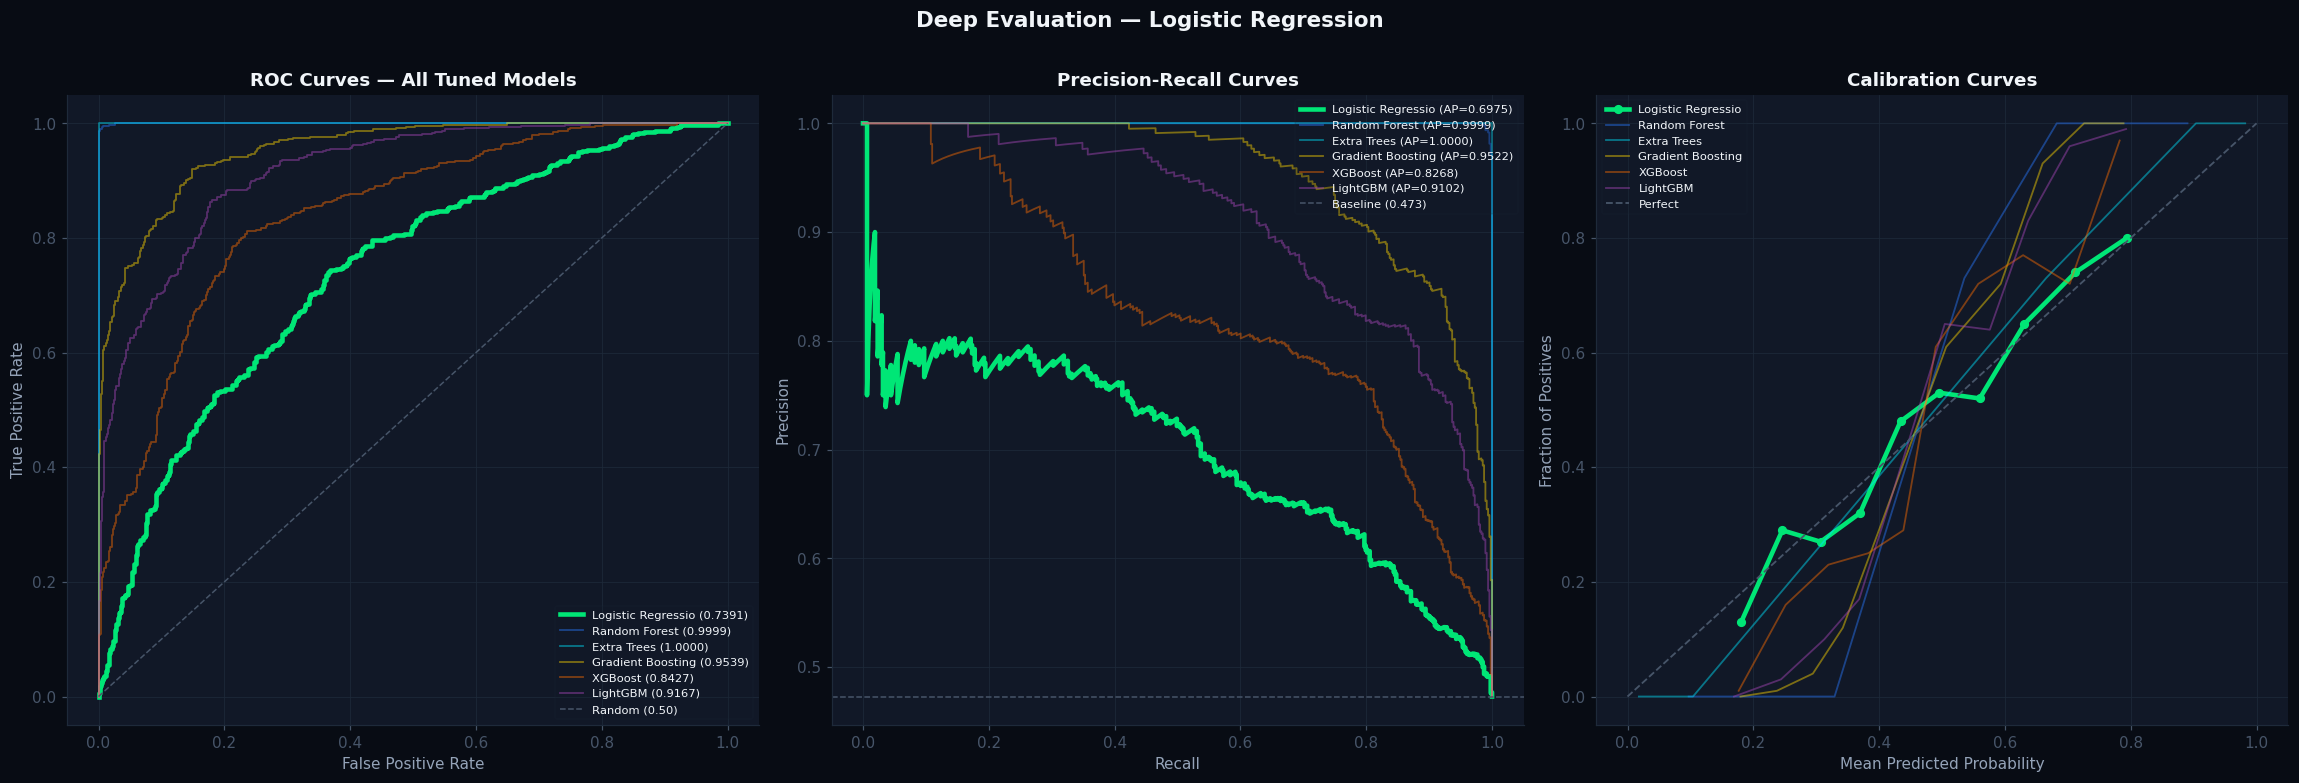

In [15]:
# ── ROC + PR + Calibration Curves ────────────────────────────────────────────
MODEL_PALETTE = ['#00e676','#2979ff','#00e5ff','#ffd600','#ff6d00',
                 '#ab47bc','#ef5350','#26a69a','#ec407a']

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f'Deep Evaluation — {best_name}', fontsize=14, fontweight='bold', y=1.01)

for i, (name, pipe) in enumerate(tuned_fitted.items()):
    try:
        yp_raw = pipe.predict_proba(X_arr)
        if yp_raw.ndim == 2:
            yp = np.array(yp_raw[:, 1], dtype=np.float64)
        else:
            yp = np.array(yp_raw, dtype=np.float64)

        if not np.all(np.isfinite(yp)):
            print(f'  Skipping {name}: non-finite probabilities')
            continue

        fpr, tpr, _ = roc_curve(y_arr.astype(float), yp)
        auc_val      = float(auc(fpr, tpr))
        prec, rec, _ = precision_recall_curve(y_arr.astype(float), yp)
        ap_val       = float(average_precision_score(y_arr.astype(float), yp))
        pt, pp       = calibration_curve(y_arr.astype(float), yp, n_bins=10, strategy='quantile')

        is_best   = (name == best_name)
        lw        = 3.0 if is_best else 1.2
        al        = 1.0 if is_best else 0.45
        mk        = 'o' if is_best else None
        color     = C_GREEN if is_best else MODEL_PALETTE[i % len(MODEL_PALETTE)]

        axes[0].plot(np.array(fpr, dtype=float), np.array(tpr, dtype=float),
                     linewidth=lw, alpha=al, color=color,
                     label=f'{name[:18]} ({auc_val:.4f})')
        axes[1].plot(np.array(rec, dtype=float), np.array(prec, dtype=float),
                     linewidth=lw, alpha=al, color=color,
                     label=f'{name[:18]} (AP={ap_val:.4f})')
        axes[2].plot(np.array(pp, dtype=float), np.array(pt, dtype=float),
                     linewidth=lw, alpha=al, color=color, marker=mk, markersize=5,
                     label=name[:18])
    except Exception as e:
        print(f'  Skipping {name}: {e}')

axes[0].plot([0,1],[0,1], color=MUTED, linestyle='--', linewidth=1, label='Random (0.50)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Tuned Models', fontweight='bold', fontsize=12)
axes[0].legend(fontsize=7.5, loc='lower right')

axes[1].axhline(float(y_arr.mean()), color=MUTED, linewidth=1, linestyle='--',
                label=f'Baseline ({y_arr.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=7.5, loc='upper right')

axes[2].plot([0,1],[0,1], color=MUTED, linestyle='--', linewidth=1.2, label='Perfect')
axes[2].set_xlabel('Mean Predicted Probability'); axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Calibration Curves', fontweight='bold', fontsize=12)
axes[2].legend(fontsize=7.5)

plt.tight_layout()
plt.show()


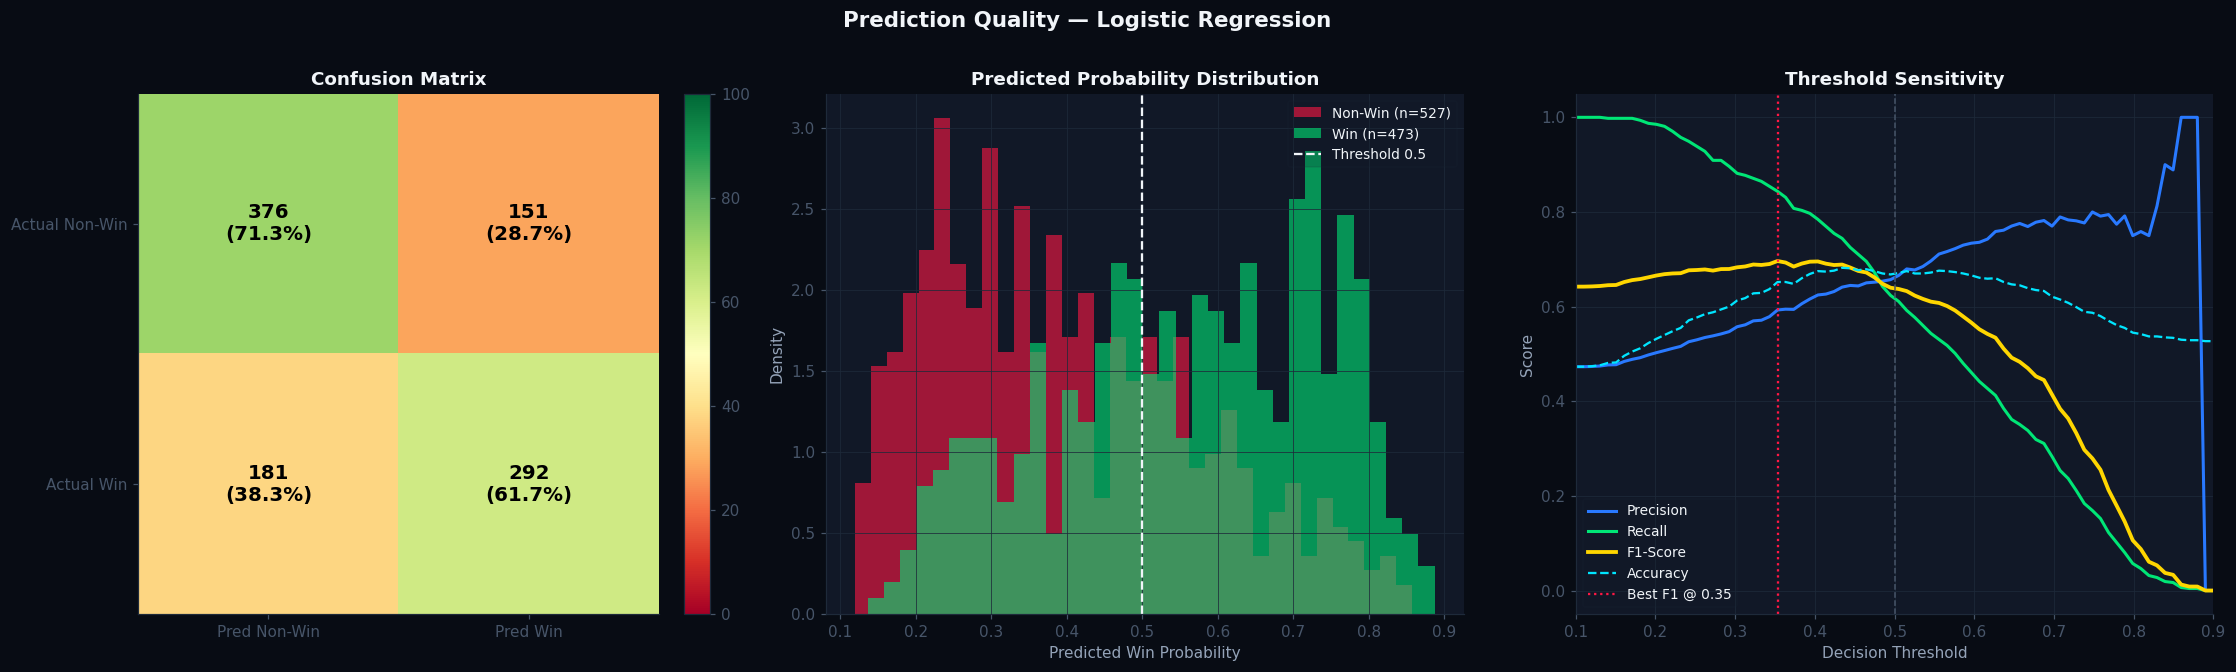

TP=292  TN=376  FP=151  FN=181
Optimal F1 threshold: 0.353
Precision @ 0.5: 0.6570  |  Recall @ 0.5: 0.6237


In [16]:
# ── Confusion Matrix + Probability Distribution + Threshold ──────────────────
y_prob_best = best_pipe.predict_proba(X_arr)[:, 1].astype(np.float64)
y_pred_best = best_pipe.predict(X_arr)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(f'Prediction Quality — {best_name}', fontsize=14, fontweight='bold', y=1.01)

# Confusion matrix
cm = confusion_matrix(y_arr, y_pred_best)
cm_pct = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True) * 100
tn, fp, fn, tp = [int(x) for x in cm.ravel()]

im = axes[0].imshow(cm_pct, cmap='RdYlGn', vmin=0, vmax=100)
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i,
                     str(cm[i,j]) + '\n(' + f'{cm_pct[i,j]:.1f}' + '%)',
                     ha='center', va='center',
                     fontsize=13, fontweight='bold', color='black')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Pred Non-Win','Pred Win'])
axes[0].set_yticks([0,1]); axes[0].set_yticklabels(['Actual Non-Win','Actual Win'])
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=12)
axes[0].grid(False)

# Probability histogram
for label, color, lname in [(0, C_RED, 'Non-Win'), (1, C_GREEN, 'Win')]:
    d = y_prob_best[y_arr == label]
    axes[1].hist(d.astype(float), bins=35, density=True, alpha=0.6,
                 color=color, label=f'{lname} (n={len(d)})', edgecolor='none')
axes[1].axvline(0.5, color=TXT, linestyle='--', linewidth=1.5, label='Threshold 0.5')
axes[1].set_xlabel('Predicted Win Probability'); axes[1].set_ylabel('Density')
axes[1].set_title('Predicted Probability Distribution', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)

# Threshold sensitivity
thresholds = np.linspace(0.1, 0.9, 80)
precs, recs, f1s_t, accs_t = [], [], [], []
for th in thresholds:
    yp_t   = (y_prob_best >= th).astype(int)
    tp_t   = float(np.sum((yp_t == 1) & (y_arr == 1)))
    fp_t   = float(np.sum((yp_t == 1) & (y_arr == 0)))
    fn_t   = float(np.sum((yp_t == 0) & (y_arr == 1)))
    prec_v = tp_t / max(1.0, tp_t + fp_t)
    rec_v  = tp_t / max(1.0, tp_t + fn_t)
    f1_v   = 2 * prec_v * rec_v / max(1e-9, prec_v + rec_v)
    precs.append(prec_v); recs.append(rec_v)
    f1s_t.append(f1_v)
    accs_t.append(float(accuracy_score(y_arr, yp_t)))

axes[2].plot(thresholds, precs,  color=C_BLUE,  linewidth=2,   label='Precision')
axes[2].plot(thresholds, recs,   color=C_GREEN, linewidth=2,   label='Recall')
axes[2].plot(thresholds, f1s_t,  color=C_GOLD,  linewidth=2.5, label='F1-Score')
axes[2].plot(thresholds, accs_t, color=C_CYAN,  linewidth=1.5, label='Accuracy', linestyle='--')
best_th_idx = int(np.argmax(f1s_t))
best_th     = float(thresholds[best_th_idx])
axes[2].axvline(best_th, color=C_RED, linewidth=1.5, linestyle=':', label=f'Best F1 @ {best_th:.2f}')
axes[2].axvline(0.5, color=MUTED, linewidth=1, linestyle='--')
axes[2].set_xlabel('Decision Threshold'); axes[2].set_ylabel('Score')
axes[2].set_title('Threshold Sensitivity', fontweight='bold', fontsize=12)
axes[2].legend(fontsize=9); axes[2].set_xlim(0.1, 0.9)

plt.tight_layout()
plt.show()

print(f'TP={tp}  TN={tn}  FP={fp}  FN={fn}')
print(f'Optimal F1 threshold: {best_th:.3f}')
print(f'Precision @ 0.5: {precs[39]:.4f}  |  Recall @ 0.5: {recs[39]:.4f}')


## 7 · Learning Curves — Bias-Variance Diagnosis


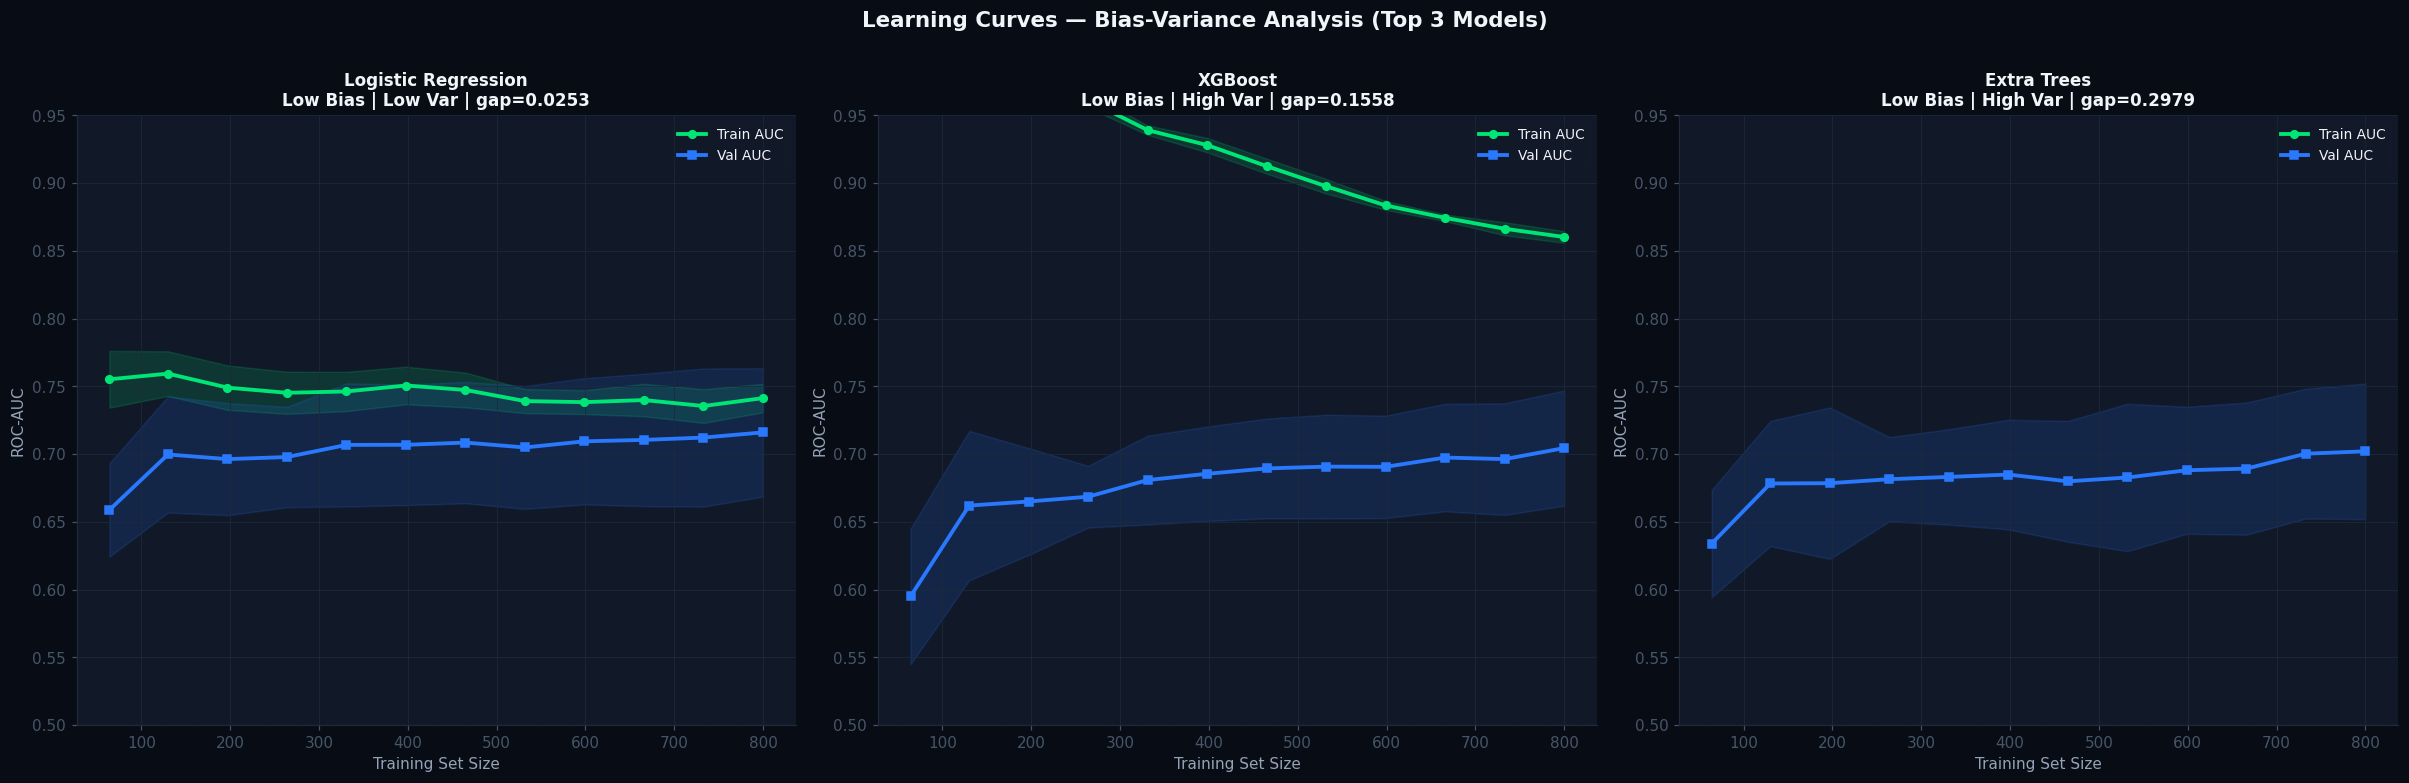

In [17]:
# ── Learning Curves for Top 3 Models ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Learning Curves — Bias-Variance Analysis (Top 3 Models)',
             fontsize=14, fontweight='bold', y=1.01)

top3_tuned = [best_name] + [n for n in comp_df['Model'].tolist()[1:] if n != best_name][:2]

for ax, name in zip(axes, top3_tuned):
    pipe = tuned_fitted[name]
    train_sizes, tr_sc, val_sc = learning_curve(
        pipe, X_arr, y_arr.astype(float), cv=SKF,
        train_sizes=np.linspace(0.08, 1.0, 12),
        scoring='roc_auc', n_jobs=-1
    )
    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    va_m, va_s = val_sc.mean(1), val_sc.std(1)

    ax.plot(train_sizes, tr_m, color=C_GREEN, linewidth=2.5, marker='o', markersize=5,
            label='Train AUC')
    ax.fill_between(train_sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color=C_GREEN)
    ax.plot(train_sizes, va_m, color=C_BLUE, linewidth=2.5, marker='s', markersize=5,
            label='Val AUC')
    ax.fill_between(train_sizes, va_m-va_s, va_m+va_s, alpha=0.15, color=C_BLUE)

    gap = tr_m[-1] - va_m[-1]
    bias  = 'Low Bias'   if va_m[-1] > 0.70 else 'High Bias'
    var   = 'Low Var'    if gap < 0.05 else 'High Var'
    ax.set_title(f'{name}\n{bias} | {var} | gap={gap:.4f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Training Set Size'); ax.set_ylabel('ROC-AUC')
    ax.set_ylim(0.5, 0.95); ax.legend(fontsize=9)
    ax.axhline(0.5, color=C_RED, linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 8 · Feature Importance & Explainability


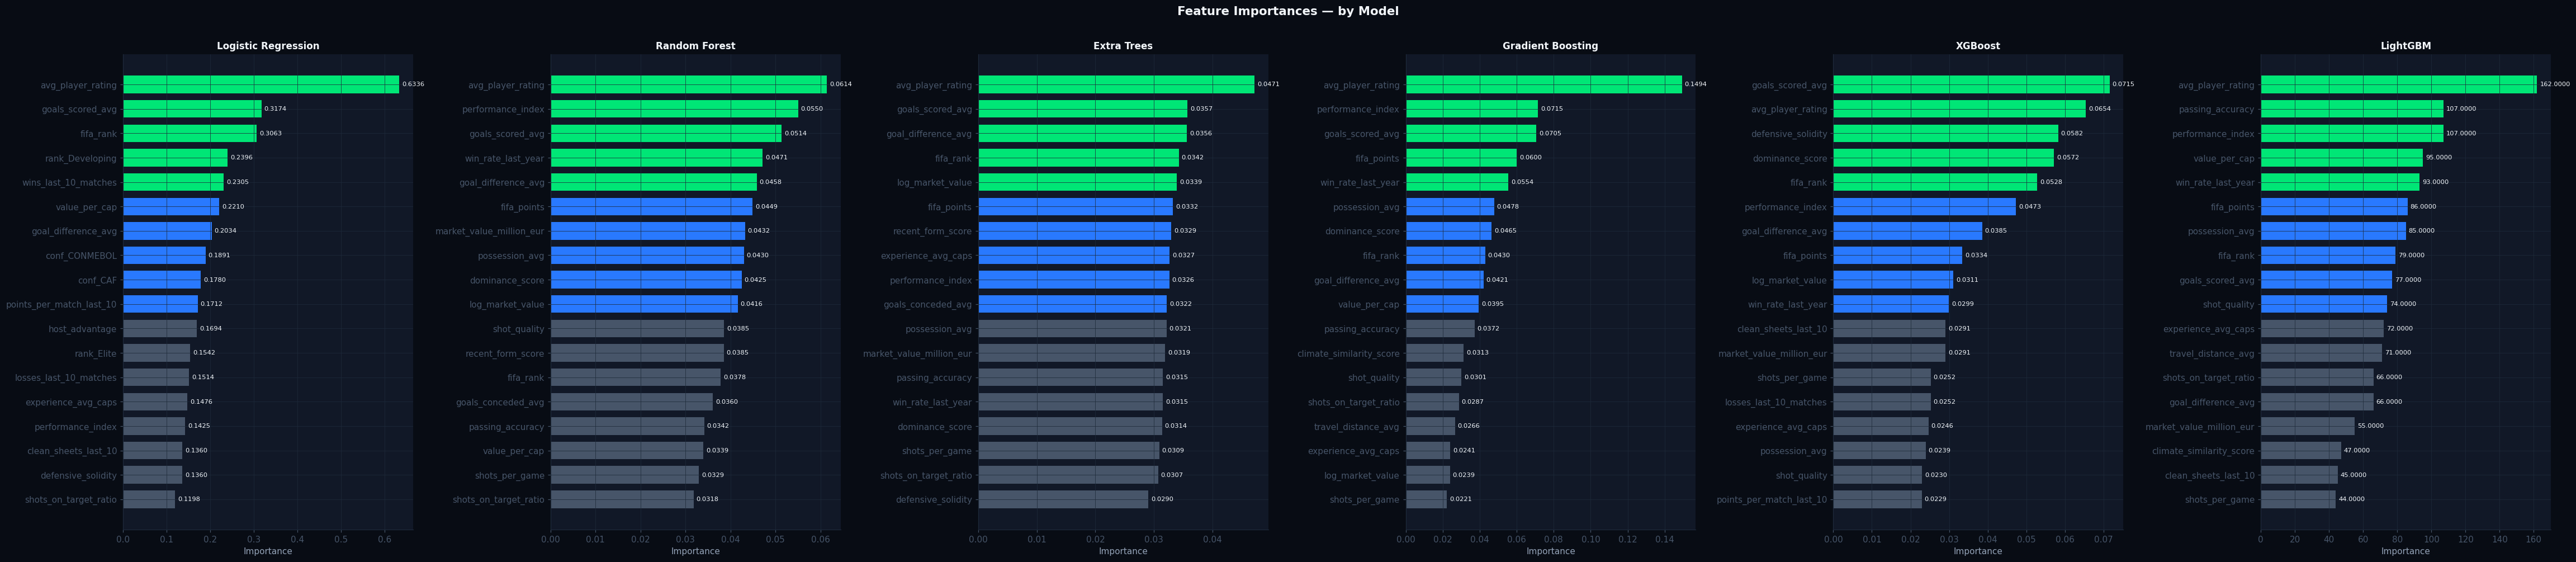

In [18]:
# ── Feature Importance — All Tree Models ─────────────────────────────────────
fi_results = {}
for name, pipe in tuned_fitted.items():
    clf = pipe.named_steps['clf']
    if hasattr(clf, 'feature_importances_'):
        fi_results[name] = np.array(clf.feature_importances_, dtype=np.float64)
    elif hasattr(clf, 'coef_'):
        fi_results[name] = np.array(np.abs(clf.coef_[0]), dtype=np.float64)

if not fi_results:
    print('No feature importances available')
else:
    fig, axes = plt.subplots(1, len(fi_results), figsize=(7*len(fi_results), 9))
    if len(fi_results) == 1: axes = [axes]
    fig.suptitle('Feature Importances — by Model', fontsize=14, fontweight='bold', y=1.01)

    for ax, (name, imps) in zip(axes, fi_results.items()):
        top_n = 18
        fi_df = pd.DataFrame({'feature':feat_cols,'imp':imps})                  .sort_values('imp',ascending=False).head(top_n)
        bar_c = [C_GREEN if i < 5 else C_BLUE if i < 10 else MUTED for i in range(len(fi_df))]
        ax.barh(fi_df['feature'][::-1], fi_df['imp'][::-1],
                color=bar_c[::-1], edgecolor='none', height=0.72)
        ax.set_title(name, fontweight='bold', fontsize=11)
        ax.set_xlabel('Importance')
        for i, (feat, imp) in enumerate(zip(fi_df['feature'][::-1], fi_df['imp'][::-1])):
            ax.text(imp+fi_df['imp'].max()*0.01, i, f'{imp:.4f}',
                    va='center', fontsize=7.5, color=TXT)

    plt.tight_layout()
    plt.show()


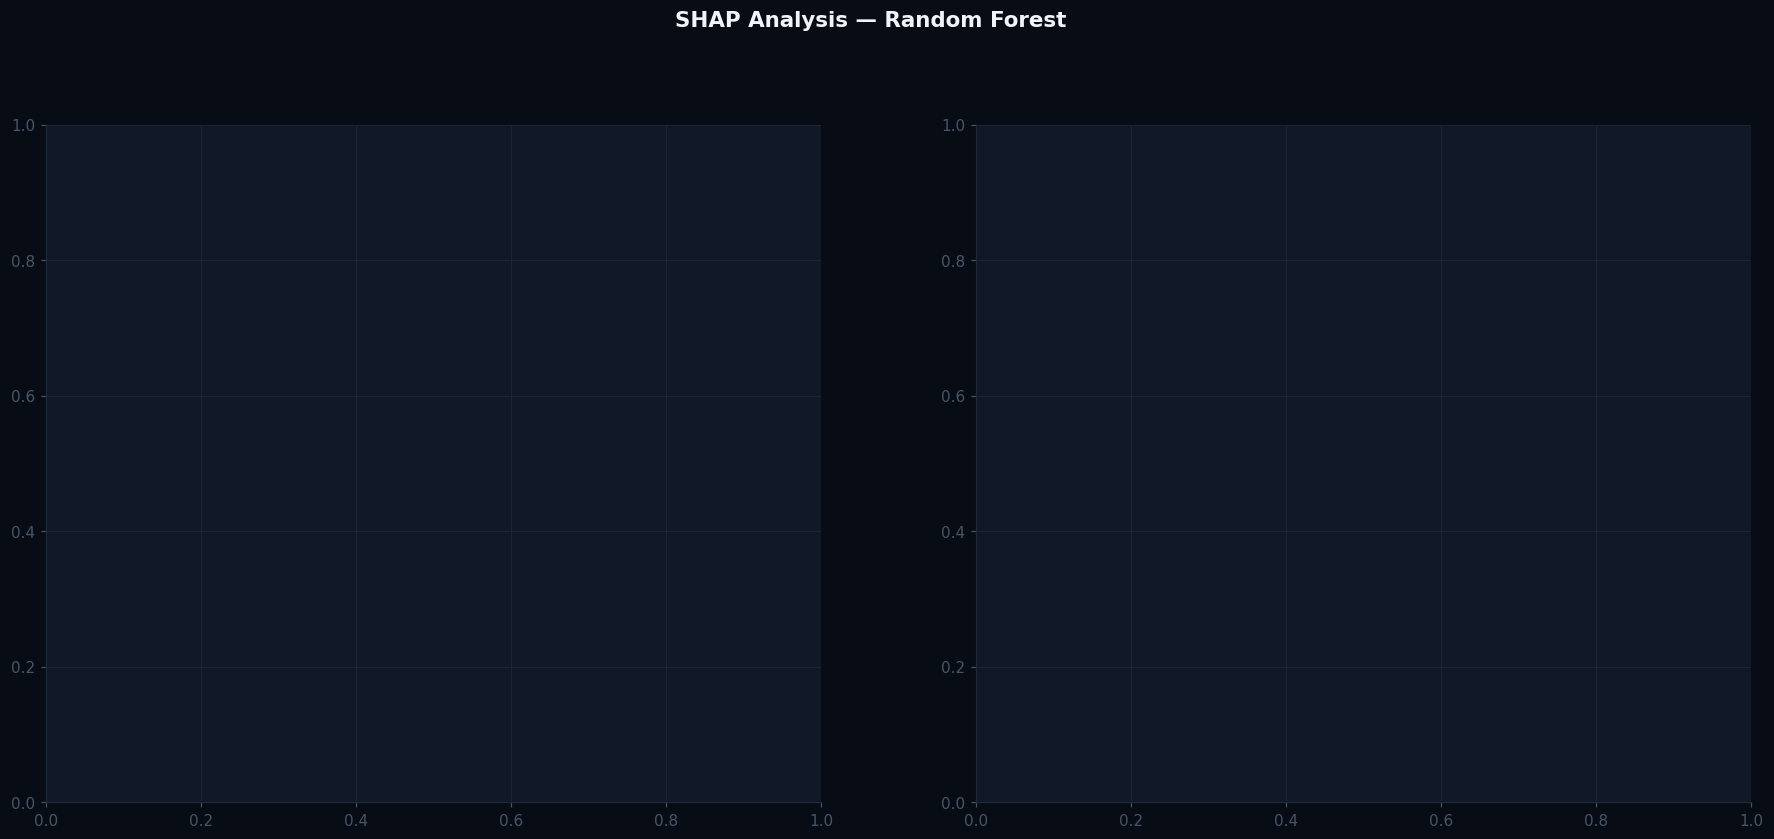

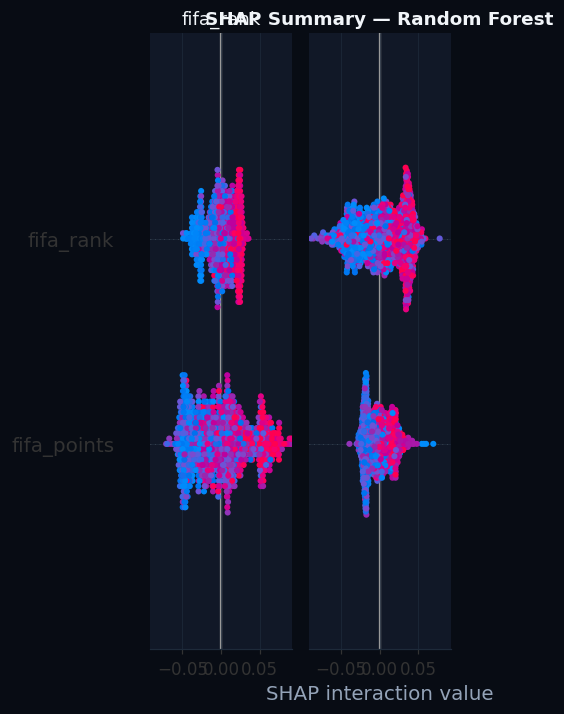

SHAP failed for Random Forest: Per-column arrays must each be 1-dimensional


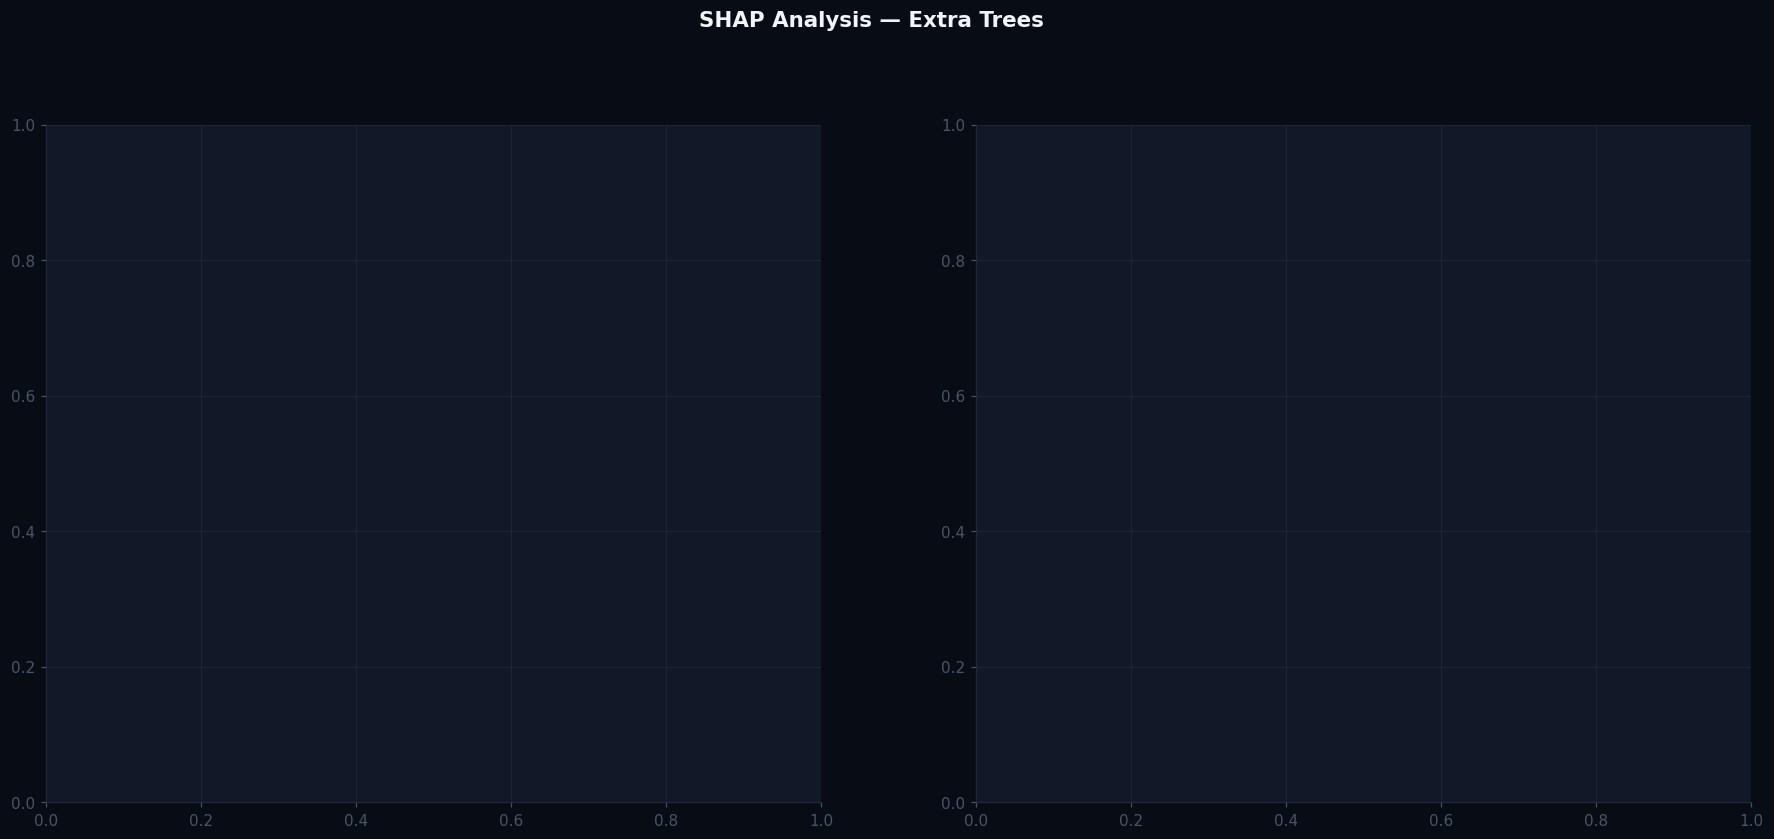

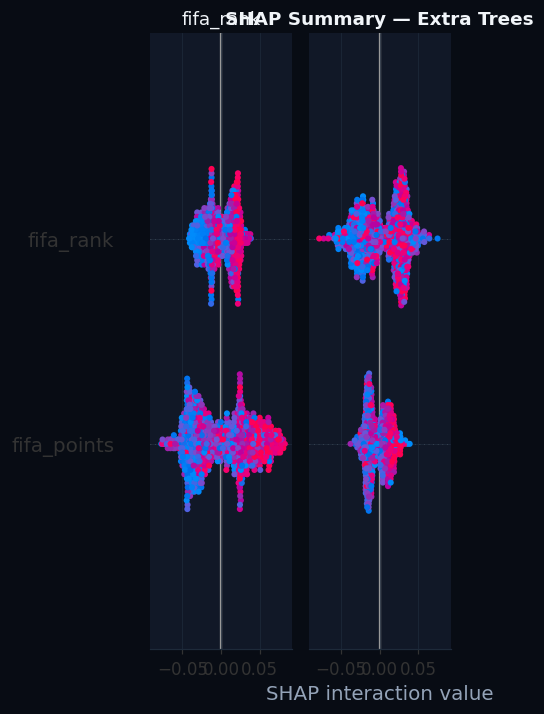

SHAP failed for Extra Trees: Per-column arrays must each be 1-dimensional


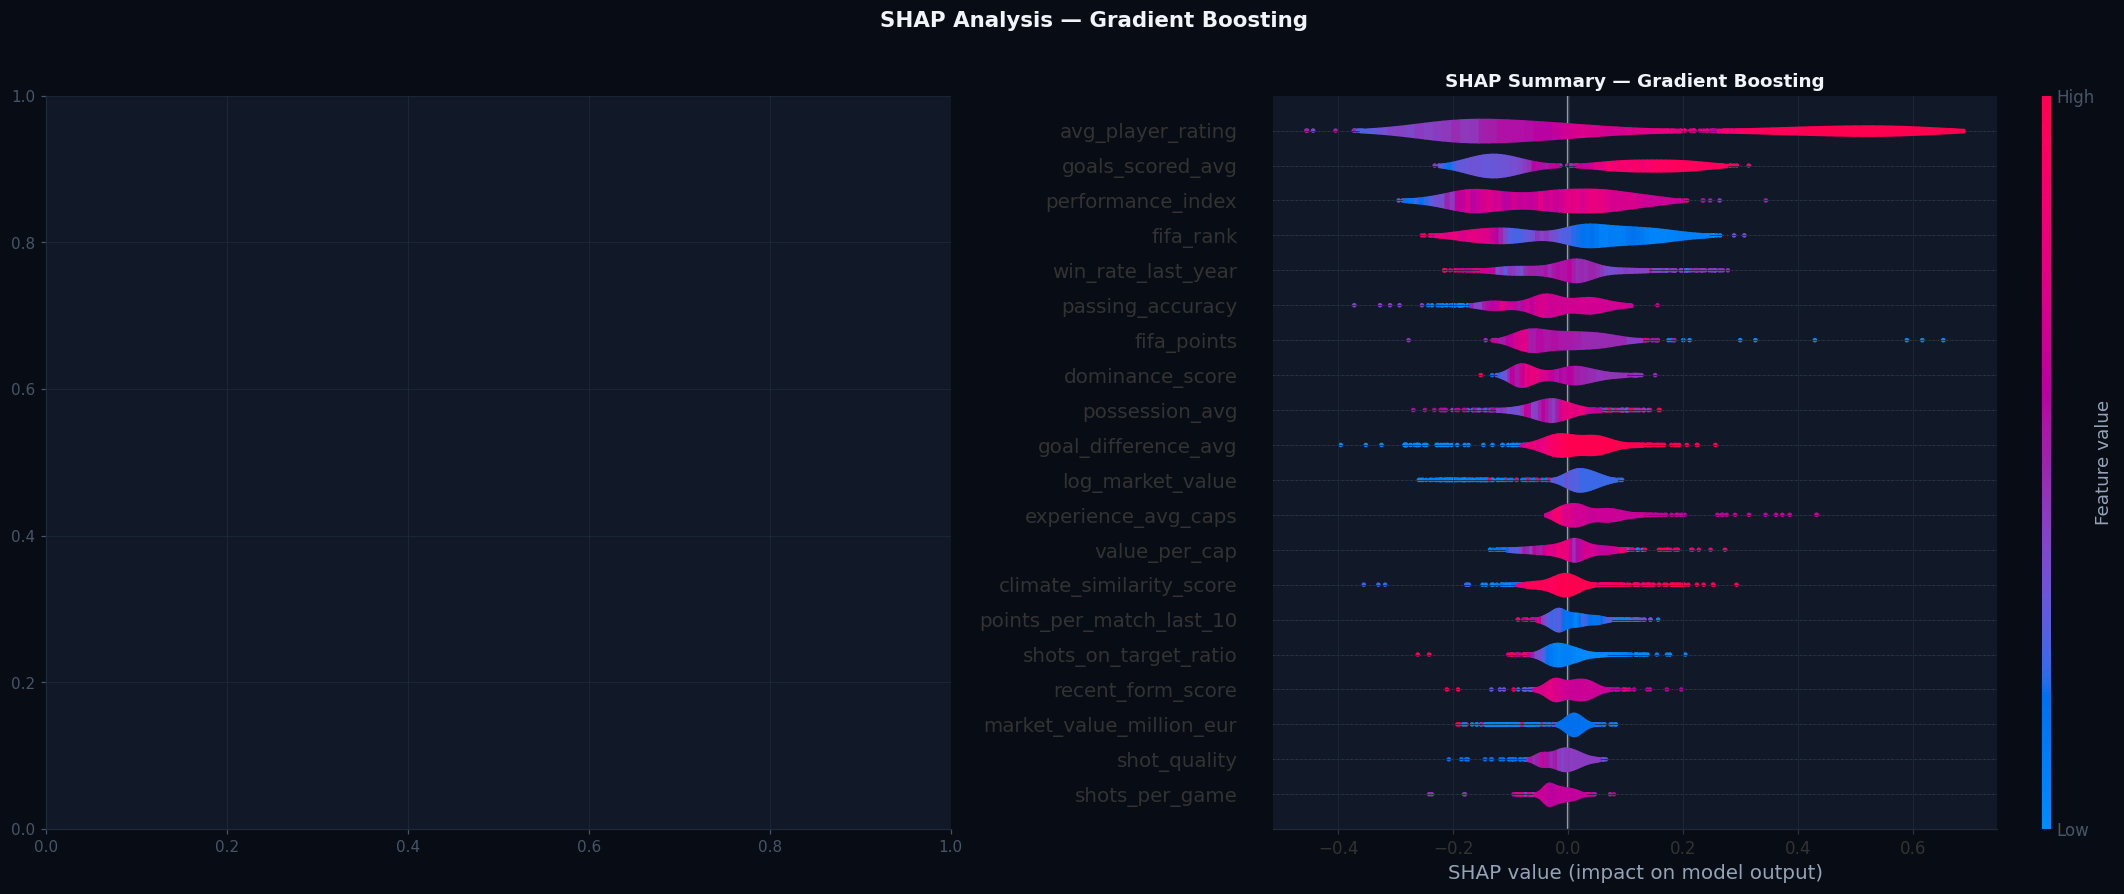

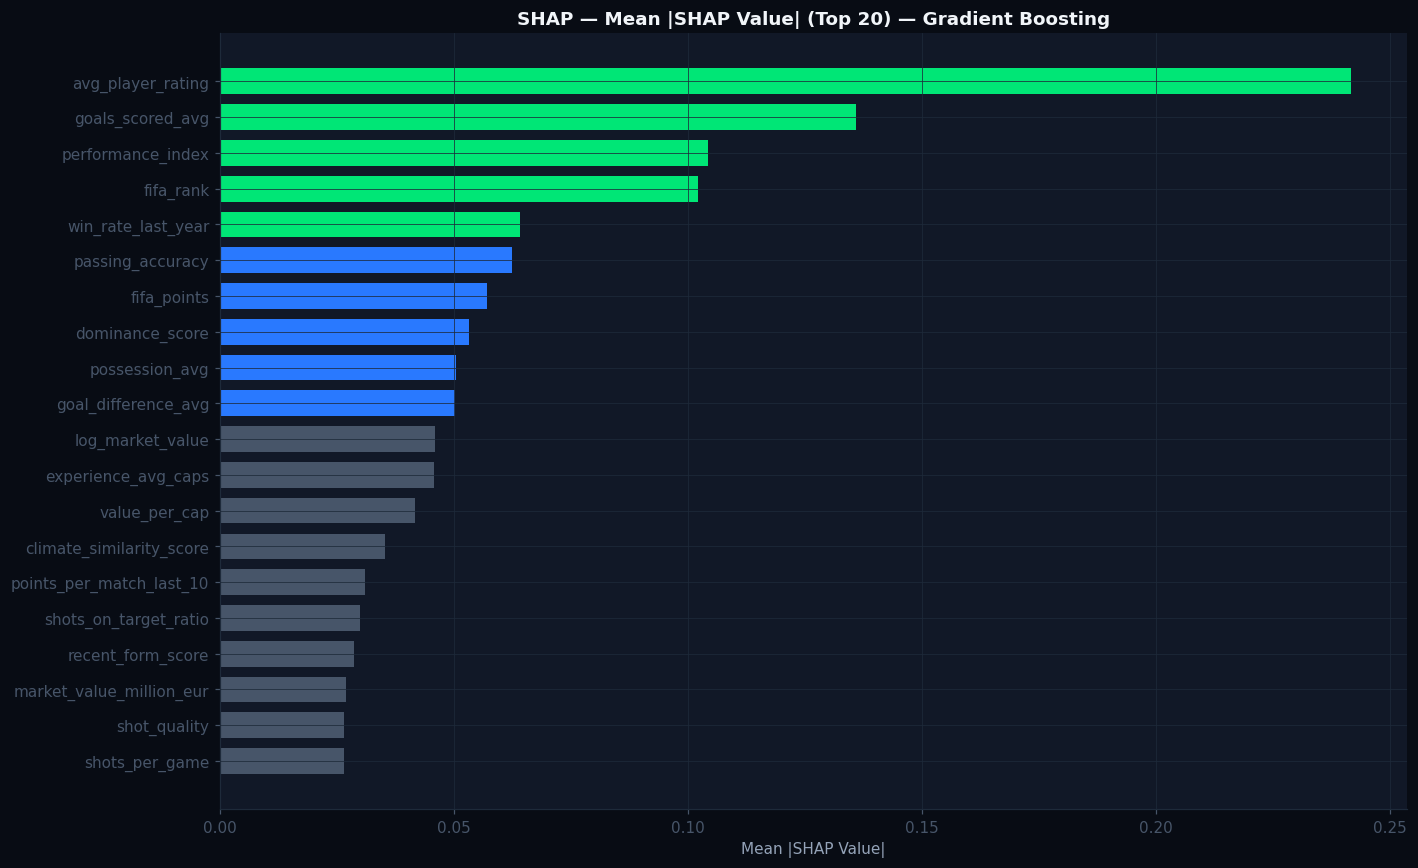

SHAP analysis completed for: Gradient Boosting


In [19]:
# ── SHAP Values (if XGBoost/LightGBM available) ──────────────────────────────
shap_done = False
for name in [best_name] + list(tuned_fitted.keys()):
    clf = tuned_fitted[name].named_steps['clf']
    if type(clf).__name__ in ('XGBClassifier','LGBMClassifier','RandomForestClassifier',
                               'ExtraTreesClassifier','GradientBoostingClassifier'):
        try:
            import shap
            # Transform X through imputer+scaler only
            pre  = Pipeline(tuned_fitted[name].steps[:-1])
            X_tf = pre.transform(X_arr)
            X_tf_df = pd.DataFrame(X_tf, columns=feat_cols)

            explainer = shap.TreeExplainer(clf)
            shap_vals  = explainer.shap_values(X_tf_df)

            if isinstance(shap_vals, list): shap_vals = shap_vals[1]

            fig, axes = plt.subplots(1, 2, figsize=(20, 8))
            fig.suptitle(f'SHAP Analysis — {name}', fontsize=14, fontweight='bold', y=1.01)

            # Summary beeswarm
            shap.summary_plot(shap_vals, X_tf_df, plot_type='violin', show=False,
                              plot_size=None, color_bar=True)
            plt.gcf().set_facecolor(DARK)
            plt.title(f'SHAP Summary — {name}', fontweight='bold')
            plt.tight_layout()
            plt.show()

            # Mean absolute bar
            mean_shap = pd.DataFrame({
                'feature': feat_cols,
                'mean_abs_shap': np.abs(shap_vals).mean(0)
            }).sort_values('mean_abs_shap', ascending=False).head(20)

            fig, ax = plt.subplots(figsize=(13, 8))
            bar_c = [C_GREEN if i < 5 else C_BLUE if i < 10 else MUTED for i in range(len(mean_shap))]
            ax.barh(mean_shap['feature'][::-1], mean_shap['mean_abs_shap'][::-1],
                    color=bar_c[::-1], edgecolor='none', height=0.72)
            ax.set_title(f'SHAP — Mean |SHAP Value| (Top 20) — {name}', fontweight='bold', fontsize=12)
            ax.set_xlabel('Mean |SHAP Value|')
            plt.tight_layout()
            plt.show()

            shap_done = True
            print(f'SHAP analysis completed for: {name}')
            break
        except Exception as e:
            print(f'SHAP failed for {name}: {e}')
            continue

if not shap_done:
    # Coefficient plot for linear model
    for name, pipe in tuned_fitted.items():
        clf = pipe.named_steps['clf']
        if hasattr(clf, 'coef_'):
            coef_df = pd.DataFrame({'feature':feat_cols,'coef':clf.coef_[0]})                        .sort_values('coef')
            top12 = pd.concat([coef_df.tail(8), coef_df.head(8)])
            fig, ax = plt.subplots(figsize=(13, 8))
            bar_c = [C_GREEN if v > 0 else C_RED for v in top12['coef']]
            ax.barh(top12['feature'], top12['coef'], color=bar_c, edgecolor='none', height=0.72)
            ax.axvline(0, color=TXT, linewidth=0.8)
            ax.set_title(f'Logistic Regression Coefficients — {name}', fontweight='bold', fontsize=12)
            ax.set_xlabel('Coefficient (positive = increases win probability)')
            plt.tight_layout()
            plt.show()
            break


## 9 · Save Artefacts & Generate Submission


In [20]:
# ── Save Best Model & Metadata ───────────────────────────────────────────────
import os
os.makedirs('../models', exist_ok=True)

# Fit best pipeline on full training data
best_pipe.fit(X_arr, y_arr)
y_prob_final = best_pipe.predict_proba(X_arr)[:, 1].astype(np.float64).astype(float)
y_pred_final = best_pipe.predict(X_arr)

train_auc  = roc_auc_score(y_arr, y_prob_final)
train_acc  = accuracy_score(y_arr, y_pred_final)
train_f1   = f1_score(y_arr, y_pred_final)
train_loss = log_loss(y_arr, y_prob_final)

# Save pipeline
joblib.dump(best_pipe, '../models/best_model.pkl')
print('✅ models/best_model.pkl')

# Save feature columns
with open('../models/feature_columns.json','w') as f:
    json.dump(feat_cols, f, indent=2)
print('✅ models/feature_columns.json')

# Build final comparison table
final_comp = comp_df[['Model','CV AUC','Train AUC','Train Acc','Train F1','MCC','Brier']]               .copy().sort_values('CV AUC', ascending=False)
final_comp.to_csv('../models/model_comparison.csv', index=False)
print('✅ models/model_comparison.csv')

# Metadata
best_params_clean = {k.replace('clf__',''): v
                     for k, v in tuning_results[best_name]['best_params'].items()}
metadata = {
    'model_name':     best_name,
    'problem_type':   'Binary Classification',
    'target_variable':'winner',
    'dataset_size':   len(X_arr),
    'n_features':     len(feat_cols),
    'cv_roc_auc':     float(comp_df.iloc[0]['CV AUC']),
    'train_roc_auc':  round(train_auc, 4),
    'train_accuracy': round(train_acc, 4),
    'train_f1':       round(train_f1, 4),
    'train_log_loss': round(train_loss, 4),
    'best_params':    best_params_clean,
    'model_comparison': final_comp.to_dict(orient='records'),
}
with open('../models/model_metadata.json','w') as f:
    json.dump(metadata, f, indent=2, default=float)
print('✅ models/model_metadata.json')


✅ models/best_model.pkl
✅ models/feature_columns.json
✅ models/model_comparison.csv
✅ models/model_metadata.json


In [21]:
# ── Generate Test Predictions ─────────────────────────────────────────────────
for col in feat_cols:
    if col not in test_df.columns:
        test_df[col] = 0

X_test = test_df[feat_cols].values.astype(float)
test_probs = best_pipe.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({'id': range(len(test_probs)),
                           'winner_probability': test_probs.round(6)})
os.makedirs('../data/processed', exist_ok=True)
submission.to_csv('../data/processed/submission.csv', index=False)

print('Submission preview:')
print(submission.head(10).to_string(index=False))
print()
print(f'✅ data/processed/submission.csv  ({len(submission)} rows)')
print(f'   Min={test_probs.min():.4f}  Max={test_probs.max():.4f}  '
      f'Mean={test_probs.mean():.4f}  Median={np.median(test_probs):.4f}')


Submission preview:
 id  winner_probability
  0            0.818945
  1            0.424170
  2            0.578472
  3            0.348146
  4            0.586637
  5            0.632907
  6            0.702586
  7            0.816573
  8            0.299238
  9            0.472030

✅ data/processed/submission.csv  (250 rows)
   Min=0.1403  Max=0.8888  Mean=0.5084  Median=0.5130


## 10 · Final Summary


In [22]:
# ── Print Full Summary ───────────────────────────────────────────────────────
print()
print('╔══════════════════════════════════════════════════════════════════════════╗')
print('║        ScoutIQ · Multi-Model ML Pipeline · Final Results                ║')
print('╠══════════════════════════════════════════════════════════════════════════╣')
print(f'║  Models Benchmarked  : {len(candidates):<49} ║')
print(f'║  Models Tuned        : {len(search_spaces):<49} ║')
print(f'║  Tuning Iterations   : {N_ITER} per model (RandomizedSearchCV){" "*14} ║')
print(f'║  Cross-Validation    : {N_FOLDS}-Fold Stratified{" "*31} ║')
print('╠══════════════════════════════════════════════════════════════════════════╣')
print(f'║  Best Model          : {best_name:<49} ║')
print(f'║  CV ROC-AUC          : {float(comp_df.iloc[0]["CV AUC"]):<49.4f} ║')
print(f'║  Train ROC-AUC       : {train_auc:<49.4f} ║')
print(f'║  Train Accuracy      : {train_acc:<49.4f} ║')
print(f'║  Train F1-Score      : {train_f1:<49.4f} ║')
print(f'║  Train Log Loss      : {train_loss:<49.4f} ║')
print('╠══════════════════════════════════════════════════════════════════════════╣')
print('║  All Model Rankings (by CV AUC):                                         ║')
for i, row in comp_df.iterrows():
    marker = '★' if row['Model'] == best_name else ' '
    auc_val = float(row['CV AUC'])
    print(f'║  {marker} {row["Model"]:<24} CV-AUC={auc_val:.4f}{" "*20} ║')
print('╠══════════════════════════════════════════════════════════════════════════╣')
print('║  Artefacts: models/best_model.pkl · feature_columns.json               ║')
print('║             model_metadata.json  · model_comparison.csv                ║')
print('║             data/processed/submission.csv                               ║')
print('╠══════════════════════════════════════════════════════════════════════════╣')
print('║  Run: python app.py  →  http://localhost:5000                            ║')
print('╚══════════════════════════════════════════════════════════════════════════╝')



╔══════════════════════════════════════════════════════════════════════════╗
║        ScoutIQ · Multi-Model ML Pipeline · Final Results                ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Models Benchmarked  : 7                                                 ║
║  Models Tuned        : 6                                                 ║
║  Tuning Iterations   : 10 per model (RandomizedSearchCV)               ║
║  Cross-Validation    : 5-Fold Stratified                                ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Best Model          : Logistic Regression                               ║
║  CV ROC-AUC          : 0.7161                                            ║
║  Train ROC-AUC       : 0.7391                                            ║
║  Train Accuracy      : 0.6680                                            ║
║  Train F1-Score      : 0.6376                                            ║
║ 